In [287]:
import sys, os

project_root = '/Users/andrepfrommer/Desktop/neural_data_science_project'
sys.path.append(project_root)

poisson_gpfa_path = os.path.join(project_root, 'utils', 'poisson-gpfa')  # adjust as needed
sys.path.append(poisson_gpfa_path)

from utils.utils import *
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

In [288]:
data = load_saved_data("data_with_spikes_and_speed")

In [289]:
# Hyperparameters
NR_TEST_TRIALS = 2
XDIM = 3
NR_EM_ITER = 500
BATCH_SIZE = 2

In [290]:
class GPFADataset:
    """Create a GPFA-compatible dataset restricted to trials matching one or
    more stimulus conditions (parameter/value pairs).

    `bin_size` (seconds) rebins the native sampling resolution by summing
    consecutive native bins — useful when neural activity is sparse relative
    to the native bin size. It does not need to be an exact multiple of the
    native sampling step; it's rounded to the nearest whole number of native
    bins (minimum 1).
    """

    def __init__(
        self,
        data=None,
        session_id="B",
        stimulus="natural_scenes",
        parameters=["orientation", "temporal_frequency"],
        parameter_values=[0, 1],
        duration_min=0.25,
        bin_size=None,
    ):
        session = data["sessions"][session_id]
        spikes = np.asarray(session["spikes"], dtype=float)
        t = np.asarray(session["t"], dtype=float)
        stim_table = session["stim_tables"][stimulus].copy()
        running_speed = np.asarray(session["running_speed_filtered"][0], dtype=float)

        # Restrict to the requested condition before doing anything else.
        for parameter, parameter_value in zip(parameters, parameter_values):
            stim_table = stim_table[stim_table[parameter] == parameter_value].reset_index(drop=True)

        native_dt_sec = float(np.median(np.diff(t)))

        # Rebinning factor: round to nearest whole number of native bins.
        if bin_size is None:
            bin_factor = 1
        else:
            bin_factor = max(1, int(round(float(bin_size) / native_dt_sec)))
        dt_sec = bin_factor * native_dt_sec
        dt_ms = dt_sec * 1000.0

        # Filter presentations shorter than duration_min.
        durations = stim_table["end"] - stim_table["start"]
        min_native_samples = int(round(duration_min / native_dt_sec))
        stim_table = stim_table[durations >= min_native_samples].reset_index(drop=True)

        condition_label = ", ".join(f"{p}={v!r}" for p, v in zip(parameters, parameter_values))

        if stim_table.empty:
            # return empty dataset
            self.data = []
            self.trial_durs = []
            self.trialDur = 0
            self.binSize = dt_ms
            self.numTrials = 0
            self.ydim = spikes.shape[0]
            self.T = 0
            self.session_id = session_id
            self.stimulus = stimulus
            self.parameters = parameters
            self.parameter_values = parameter_values
            self.bin_size = dt_sec
            self.bin_factor = int(bin_factor)
            return

        # Fixed trial length: shortest presentation, truncated to a whole
        # number of bins, kept even.
        T_native = int((stim_table["end"] - stim_table["start"]).min())
        T = T_native // bin_factor
        T -= T % 2
        if T < 1:
            raise ValueError(f"bin_size is too large for the shortest valid trial ({condition_label}).")
        T_native = T * bin_factor

        max_start = min(spikes.shape[1], running_speed.shape[0]) - T_native
        stim_metadata_cols = [c for c in stim_table.columns if c not in ("start", "end")]

        trials = []
        for _, row in stim_table.iterrows():
            start_idx = int(row["start"])
            if start_idx > max_start:
                continue  # not enough samples left in the recording for this trial
            stop_idx = start_idx + T_native

            Y_native = spikes[:, start_idx:stop_idx]
            speed_native = running_speed[start_idx:stop_idx]
            if bin_factor > 1:
                ydim = Y_native.shape[0]
                Y = Y_native.reshape(ydim, T, bin_factor).sum(axis=2)
                speed = speed_native.reshape(T, bin_factor).mean(axis=1)
            else:
                Y = Y_native.copy()
                speed = speed_native.copy()

            # get spike times (from the binned counts, at the binned resolution)
            spike_time = []
            for trace in Y:
                nz = np.flatnonzero(np.isfinite(trace) & (trace > 0))
                if nz.size == 0:
                    spike_time.append(np.array([], dtype=float))
                    continue
                counts = np.maximum(1, np.rint(trace[nz]).astype(int))
                spike_time.append(np.repeat(nz, counts) * dt_sec)

            trial_dict = {
                "Y": Y,
                "spike_time": spike_time,
                "start_idx": start_idx,
                "end_idx": stop_idx,
                "running_speed": speed,
            }
            trial_dict.update({col: row[col] for col in stim_metadata_cols})
            trials.append(trial_dict)

        if not trials:
            raise ValueError(f"No trials remained for {condition_label} after bounds checks.")

        self.data = trials
        self.trial_durs = [T * dt_sec for _ in trials]
        self.trialDur = T * dt_ms
        self.binSize = dt_ms
        self.numTrials = len(trials)
        self.ydim = spikes.shape[0]
        self.T = T
        self.session_id = session_id
        self.stimulus = stimulus
        self.parameters = parameters
        self.parameter_values = parameter_values
        self.bin_size = dt_sec
        self.bin_factor = int(bin_factor)

In [291]:
# loop this over all possible temporal frequencies and orientations to create a dataset for each condition
stim_table = data["sessions"]["A"]["stim_tables"]["drifting_gratings"]

fits = {}

for orientation in stim_table["orientation"].unique():
    for temporal_frequency in stim_table["temporal_frequency"].unique():
        
        data_drifting_gratings = GPFADataset(
            data=data,
            session_id="A",
            stimulus="drifting_gratings",
            parameters=["orientation", "temporal_frequency"],
            parameter_values=[orientation, temporal_frequency],
            duration_min=1.0,
        )
        
        if data_drifting_gratings.numTrials > 10:
            print(f"Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Trials: {data_drifting_gratings.numTrials}, Trial Duration: {data_drifting_gratings.trialDur} ms, Bin Size: {data_drifting_gratings.binSize} ms")
            print(f"Fitting GPFA model for orientation {orientation} and temporal frequency {temporal_frequency}...")
            
            xval_drifting_gratings = util.crossValidation(
                experiment = data_drifting_gratings,
                numTrainingTrials = data_drifting_gratings.numTrials - NR_TEST_TRIALS,
                numTestTrials = NR_TEST_TRIALS,
                maxXdim = XDIM,
                maxEMiter = NR_EM_ITER, 
                batchSize = BATCH_SIZE,
                inferenceMethod = "laplace",
                learningMethod = "batch",
            )

            train_set, test_set = util.splitTrainingTestDataset(
                data_drifting_gratings, 
                numTrainingTrials=data_drifting_gratings.numTrials - NR_TEST_TRIALS, 
                numTestTrials=NR_TEST_TRIALS
            )
            
            fits[(orientation, temporal_frequency)] = (train_set, test_set, xval_drifting_gratings)

Orientation: 225.0, Temporal Frequency: 1.0, Trials: 15, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Fitting GPFA model for orientation 225.0 and temporal frequency 1.0...
Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                  500 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:   1 of 500, nPLL: = -16.2383

Iteration: 500 of 500, nPLL: = -16.2441Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                  500 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration: 500 of 500, nPLL: = -16.2441Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


...

/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    2 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                  500 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration: 500 of 500, nPLL: = -18.2652Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    3 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                  500 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration: 500 of 500, nPLL: = -18.2038Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/utils/poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [292]:
print("Datasets created for all combinations of orientation and temporal frequency.")
for (orientation, temporal_frequency), (train_set, test_set, xval_drifting_gratings) in fits.items():
    print(f"Orientation: {orientation}, Temporal Frequency: {temporal_frequency}, Train Trials: {train_set.numTrials}, Test Trials: {test_set.numTrials}, Trial Duration: {train_set.trialDur} ms, Bin Size: {train_set.binSize} ms")

Datasets created for all combinations of orientation and temporal frequency.
Orientation: 225.0, Temporal Frequency: 1.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 225.0, Temporal Frequency: 2.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 225.0, Temporal Frequency: 4.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 225.0, Temporal Frequency: 15.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 225.0, Temporal Frequency: 8.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 180.0, Temporal Frequency: 1.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.203125 ms
Orientation: 180.0, Temporal Frequency: 2.0, Train Trials: 13, Test Trials: 2, Trial Duration: 1925.78125 ms, Bin Size: 33.2

## Test error for different latent dimensions 

In [293]:
def baseline_error(xval, dataset) -> float:
    baseline_error = 0.0
    
    # pick the first model
    fit = xval[0]
    ydim, xdim = np.shape(fit.optimParams["C"])
    for tr in range(dataset.numTrials):
        # loop over neurons (y dimension)
        for nrn in range(dataset.ydim):
            # predict y with X the identity matrix
            x_id = np.ones((xdim, dataset.T))
            y_pred = np.exp(
                fit.optimParams["C"][nrn].dot(x_id).T + fit.optimParams["d"][nrn]
            )
            #compute SSE
            baseline_error += np.dot(
                dataset.data[tr]["Y"][nrn] - y_pred, 
                dataset.data[tr]["Y"][nrn] - y_pred
            )
    
    return baseline_error

In [294]:
# loop over all datasets and compute baseline and test errors

errors_dict = {}
for (orientation, temporal_frequency), (train_set, test_set, xval_drifting_gratings) in fits.items():
    print(f"Computing baseline and test errors for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}")
    
    # Compute baseline error
    base_error = baseline_error(xval_drifting_gratings.fits, test_set)
    
    # Compute test error using the fitted model
    errors = []
    for fit in xval_drifting_gratings.fits:
        predBatch, predErr = util.leaveOneOutPrediction(fit.optimParams, test_set)
        errors.append(predErr)
    
    errors_dict[(orientation, temporal_frequency)] = {
        "baseline_error": base_error,
        "test_errors": errors
    }

Computing baseline and test errors for Orientation: 225.0, Temporal Frequency: 1.0
Performing leave-one-out cross validation...


Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 225.0, Temporal Frequency: 2.0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 225.0, Temporal Frequency: 4.0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 225.0, Temporal Frequency: 15.0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors for Orientation: 225.0, Temporal Frequency: 8.0
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Performing leave-one-out cross validation...
Computing baseline and test errors fo

In [295]:
def plot_baseline_and_test_errors(errors_dict, orientation, temporal_frequency, figsize=(5, 4)):
    """
    Plot baseline and per-model test errors for one (orientation, temporal_frequency)
    condition, as a line over model index (xdim).

    Parameters
    ----------
    errors_dict : dict
        Maps (orientation, temporal_frequency) -> {"baseline_error": ..., "test_errors": [...]}
    orientation, temporal_frequency : float
        The specific condition to plot.
    figsize : tuple
        Figure size in inches.

    Returns
    -------
    fig, ax
    """
    errors = errors_dict.get((orientation, temporal_frequency))
    if errors is None:
        raise KeyError(f"No errors found for orientation={orientation}, temporal_frequency={temporal_frequency}")

    baseline_error_value = np.asarray(errors["baseline_error"]).mean()
    test_errors_values = [np.asarray(e).mean() for e in errors["test_errors"]]
    xdims = range(1, len(test_errors_values) + 1)

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(xdims, test_errors_values, marker="o", color="steelblue", label="Test Error")
    ax.axhline(baseline_error_value, color="red", linestyle="--", label="Baseline Error")

    ax.set_xticks(list(xdims))
    ax.set_xlabel("Latent Dimensionality (xdim)")
    ax.set_ylabel("Error")
    ax.set_title(f"Orientation {orientation:g}, TF {temporal_frequency:g}")
    ax.legend()

    fig.tight_layout()
    return fig, ax

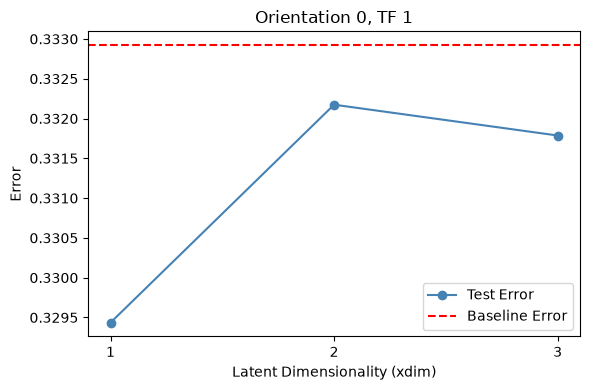

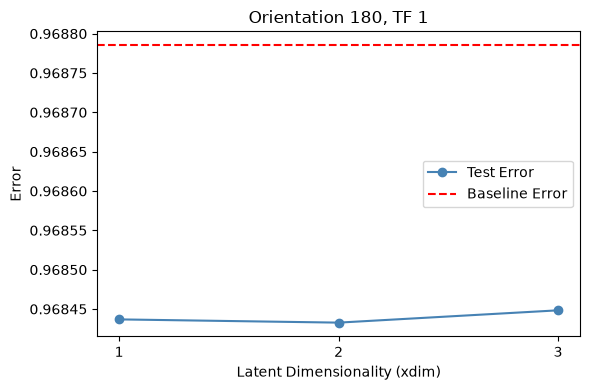

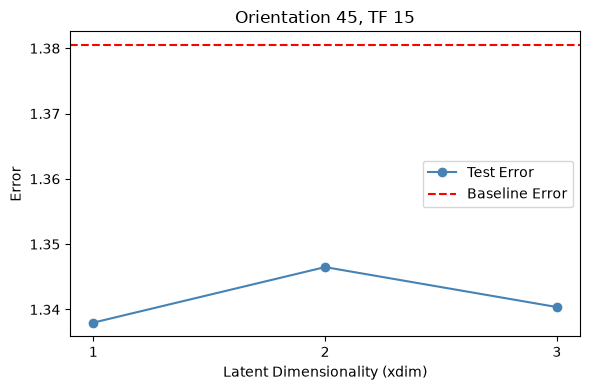

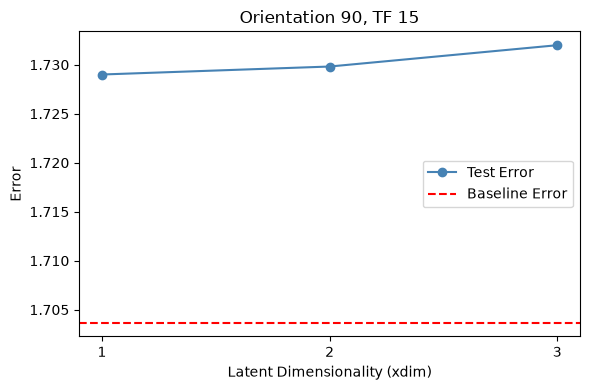

In [296]:
fig, axes = plot_baseline_and_test_errors(
    errors_dict, 
    orientation=0,  # example orientation
    temporal_frequency=1,  # example temporal frequency
    figsize=(6, 4)
)
plt.show()

fig, axes = plot_baseline_and_test_errors(
    errors_dict, 
    orientation=180,  # example orientation
    temporal_frequency=1,  # example temporal frequency
    figsize=(6, 4)
)
plt.show()

fig, axes = plot_baseline_and_test_errors(
    errors_dict, 
    orientation=45,  # example orientation
    temporal_frequency=15,  # example temporal frequency
    figsize=(6, 4)
)
plt.show()

fig, axes = plot_baseline_and_test_errors(
    errors_dict, 
    orientation=90,  # example orientation
    temporal_frequency=15,  # example temporal frequency
    figsize=(6, 4)
)
plt.show()

TODO: Is this the right way to compute the baseline error?

## Noise correlations and their analytical approximations using GPFA parameters

In [297]:
def compute_raw_cov(fits):
    raw_covariances = {}
    for (orientation, temporal_frequency), (train_set, test_set, xval_drifting_gratings) in fits.items():
        print(f"Computing raw covariance for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}")
        
        # Stack all trials' Y data into a single 2D array (neurons x time)
        all_Y = np.hstack([trial["Y"] for trial in train_set.data])
        
        # Compute the covariance matrix
        raw_covariance = np.cov(all_Y)
        
        raw_covariances[(orientation, temporal_frequency)] = raw_covariance
        
    return raw_covariances

In [298]:
def compute_cov_approx(fits):
    """
    Compute the approximate covariance matrices for each fitted model in the
    cross-validation results.

    Returns
    -------
    dict mapping (orientation, temporal_frequency) -> list of (ydim, ydim)
    covariance matrices, one per fit (e.g. one per candidate xdim).
    """
    cov_dict = {}
    for (orientation, temporal_frequency), (train_set, test_set, xval_drifting_gratings) in fits.items():
        print(f"Computing approximate covariance for Orientation: {orientation}, Temporal Frequency: {temporal_frequency}")

        approx_cov = []
        for fit in xval_drifting_gratings.fits:
            cov, _ = cov_anal(fit)
            approx_cov.append(cov)

        cov_dict[(orientation, temporal_frequency)] = approx_cov

    return cov_dict

In [299]:
raw_covs = compute_raw_cov(fits)
approx_covs = compute_cov_approx(fits)

Computing raw covariance for Orientation: 225.0, Temporal Frequency: 1.0
Computing raw covariance for Orientation: 225.0, Temporal Frequency: 2.0
Computing raw covariance for Orientation: 225.0, Temporal Frequency: 4.0
Computing raw covariance for Orientation: 225.0, Temporal Frequency: 15.0
Computing raw covariance for Orientation: 225.0, Temporal Frequency: 8.0
Computing raw covariance for Orientation: 180.0, Temporal Frequency: 1.0
Computing raw covariance for Orientation: 180.0, Temporal Frequency: 2.0
Computing raw covariance for Orientation: 180.0, Temporal Frequency: 4.0
Computing raw covariance for Orientation: 180.0, Temporal Frequency: 15.0
Computing raw covariance for Orientation: 180.0, Temporal Frequency: 8.0
Computing raw covariance for Orientation: 90.0, Temporal Frequency: 1.0
Computing raw covariance for Orientation: 90.0, Temporal Frequency: 2.0
Computing raw covariance for Orientation: 90.0, Temporal Frequency: 4.0
Computing raw covariance for Orientation: 90.0, Temp

In [300]:
def plot_covariances(raw_covs, approx_covs, orientation, temporal_frequency):
    
    # get the raw and approximate covariances for the specified orientation and temporal frequency
    raw_cov = raw_covs.get((orientation, temporal_frequency))
    approx_cov = approx_covs.get((orientation, temporal_frequency))
    if raw_cov is None or approx_cov is None:
        raise KeyError(f"No covariance data found for orientation={orientation}, temporal_frequency={temporal_frequency}")
    
    n_dims = len(approx_cov)
    fig, axes = plt.subplots(1, n_dims + 1, figsize=((n_dims + 1) * 3, 3))

    # Shared color scale across all panels so magnitudes are visually comparable.
    all_vals = [raw_cov] + list(approx_cov)
    vmax = max(np.abs(v).max() for v in all_vals)

    im0 = axes[0].imshow(raw_cov, cmap="magma", vmin=-vmax, vmax=vmax)
    axes[0].set_title("Raw Covariance")
    axes[0].set_xlabel("neuron")
    axes[0].set_ylabel("neuron")

    for i, cov in enumerate(approx_cov):
        im = axes[i + 1].imshow(cov, cmap="magma", vmin=-vmax, vmax=vmax)
        axes[i + 1].set_title(f"GPFA approx (dim={i + 1})")
        axes[i + 1].set_xlabel("neuron")
        axes[i + 1].set_ylabel("neuron")
        if i == n_dims - 1:
            fig.colorbar(im, ax=axes[i + 1], shrink=0.7, label="covariance")
    
    fig.suptitle(f"Orientation {orientation:g}°, TF {temporal_frequency:g}", fontsize=16)
    fig.tight_layout()  # leave room for suptitle

    return fig, axes

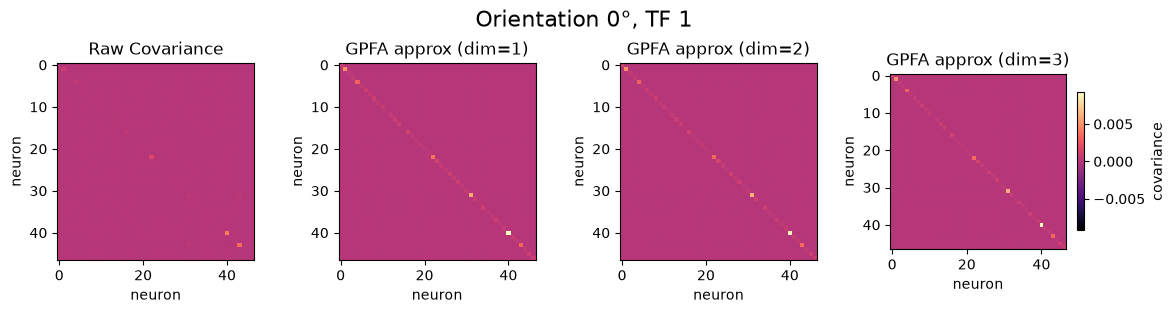

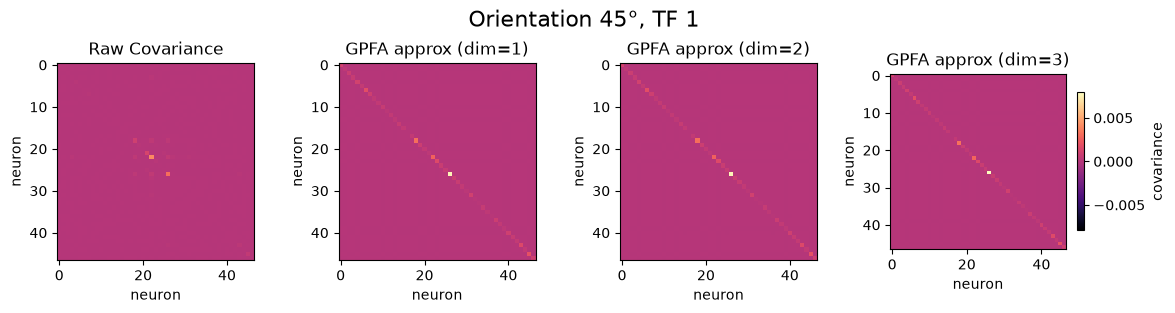

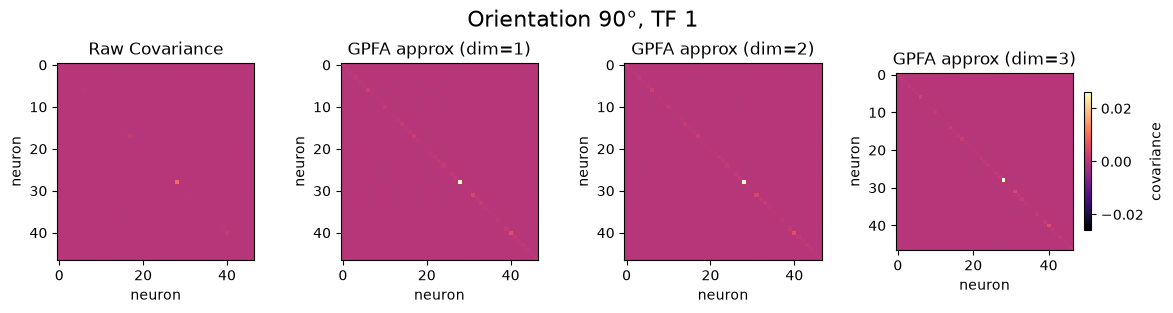

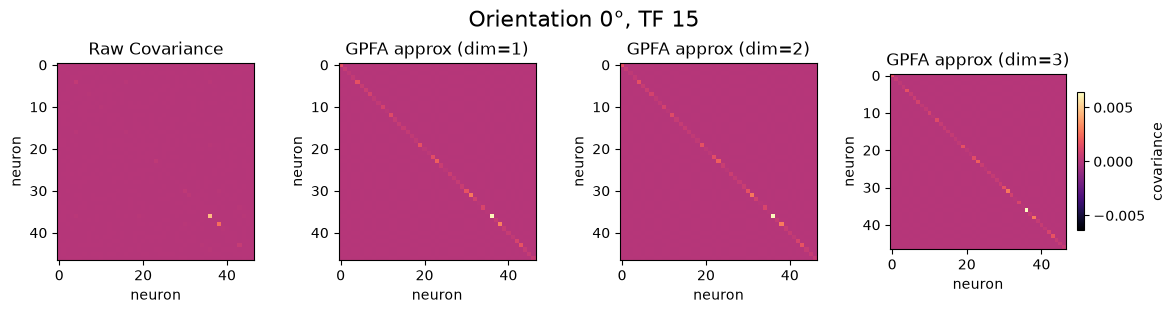

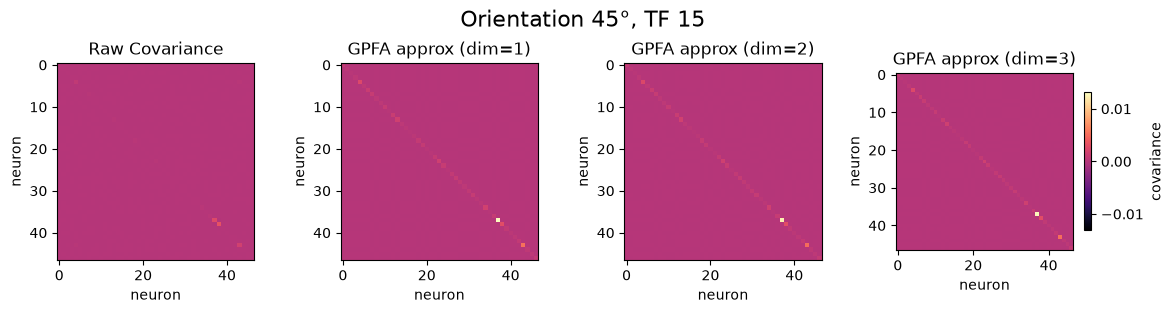

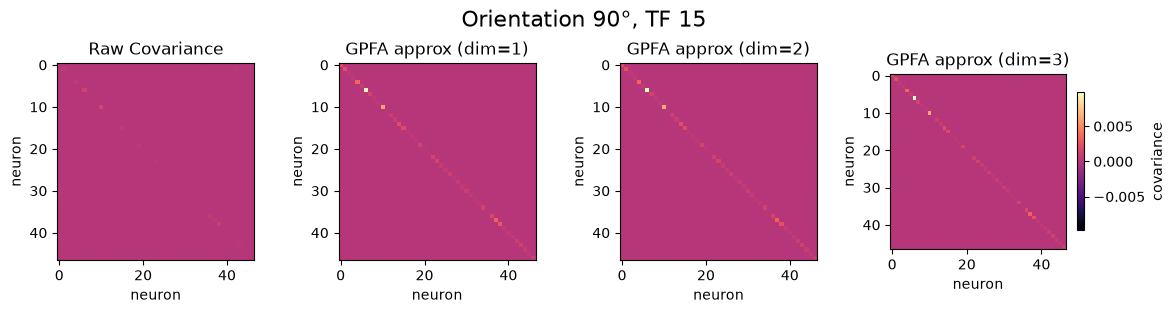

In [301]:
fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=0, 
    temporal_frequency=1
)
plt.show()

fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=45, 
    temporal_frequency=1
)
plt.show()

fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=90, 
    temporal_frequency=1
)
plt.show()

fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=0, 
    temporal_frequency=15
)
plt.show()

fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=45, 
    temporal_frequency=15
)
plt.show()

fig, axes = plot_covariances(
    raw_covs, 
    approx_covs, 
    orientation=90, 
    temporal_frequency=15
)
plt.show()

Looks like GPFA can at least reproduce the relative magnitude of the spike count for one neuron. We cannot, however, approximate correlations between neurons, like seen f.e for orientation: 30

### GPFA Model parameter distributions

In [302]:
def plot_param_histograms(
    fits,
    orientation,
    temporal_frequency,
    param_name="C",
    bins=30,
    neuron_idx=None,
):
    """
    Plot histograms of the specified parameter (e.g., 'C' or 'd')
    for all fitted models for a given orientation and temporal frequency.
    """

    fit_data = fits.get((orientation, temporal_frequency))
    if fit_data is None:
        raise KeyError(
            f"No fits found for orientation={orientation}, "
            f"temporal_frequency={temporal_frequency}"
        )

    train_set, test_set, xval_drifting_gratings = fit_data

    fig, axes = plt.subplots(
        1,
        len(xval_drifting_gratings.fits),
        figsize=(len(xval_drifting_gratings.fits) * 5, 4),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes)

    for i, fit in enumerate(xval_drifting_gratings.fits):
        params = fit.optimParams[param_name]
        param_values = params.flatten() # shape (ydim * xdim,) for 'C', shape (ydim,) for 'd' or '(n_dim,) for 'tau'

        axes[i].hist(param_values, bins=bins,
                     color="steelblue", edgecolor="black")

        if neuron_idx is not None and neuron_idx < params.shape[0]:
            if param_name == "C":
                for val in params[neuron_idx]:
                    axes[i].axvline(
                        val, 
                        color="red", 
                        linestyle="--", 
                        linewidth=2, 
                        alpha=0.7, 
                        label=f"Neuron {neuron_idx}" if i == 0 else None
                    )
            elif param_name == "d":
                axes[i].axvline(
                    params[neuron_idx],
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    alpha=0.7,
                    label=f"Neuron {neuron_idx}" if i == 0 else None
                )

        axes[i].set_title(f"xdim={i + 1}")
        if param_name == "tau":
            axes[i].set_xlabel("time (s)")
        else:
            axes[i].set_xlabel(param_name)
        axes[i].set_ylabel("Frequency")
        axes[i].legend()

    fig.suptitle(
        f"Parameter '{param_name}'\n"
        f"Orientation {orientation:g}°, TF {temporal_frequency:g}",
        fontsize=16,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.93])

    return fig, axes

/var/folders/_d/h8vy8lln5vg20dc2rt60305c0000gn/T/ipykernel_11192/2095609631.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


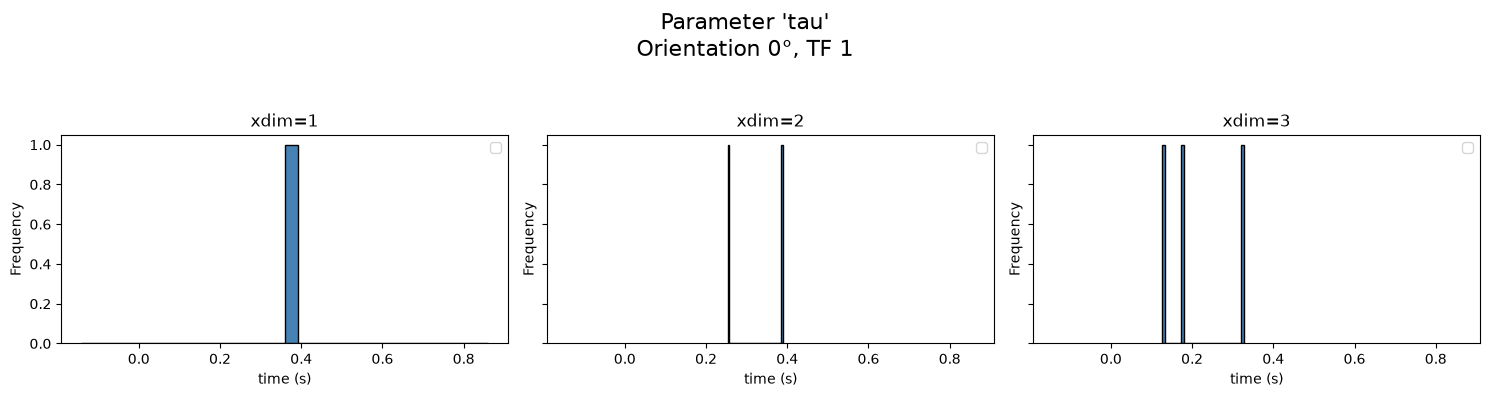

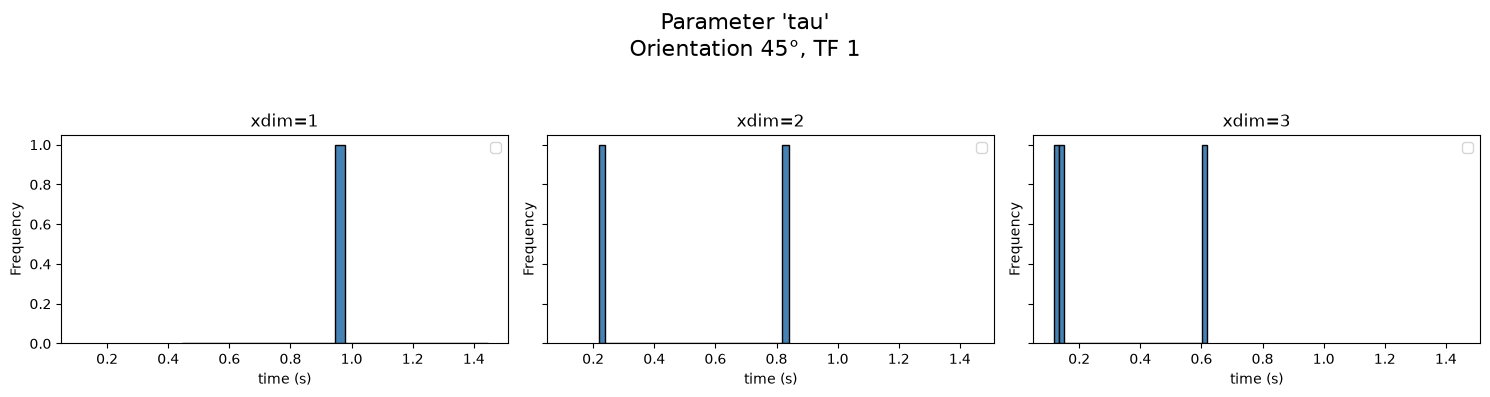

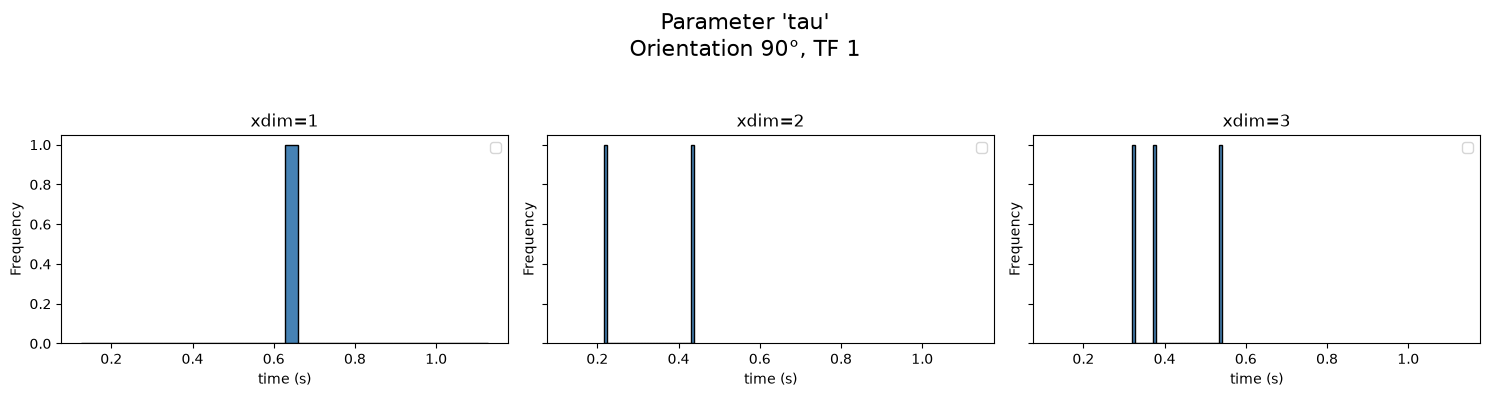

In [303]:
fig, axes = plot_param_histograms(
    fits, 
    orientation=0, 
    temporal_frequency=1, 
    param_name="tau", 
    bins=30,
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=45, 
    temporal_frequency=1, 
    param_name="tau", 
    bins=30,
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=90, 
    temporal_frequency=1, 
    param_name="tau", 
    bins=30,
)
plt.show()

time constant relatively slow (around 0.2 - 0.4s)

/var/folders/_d/h8vy8lln5vg20dc2rt60305c0000gn/T/ipykernel_11192/2095609631.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


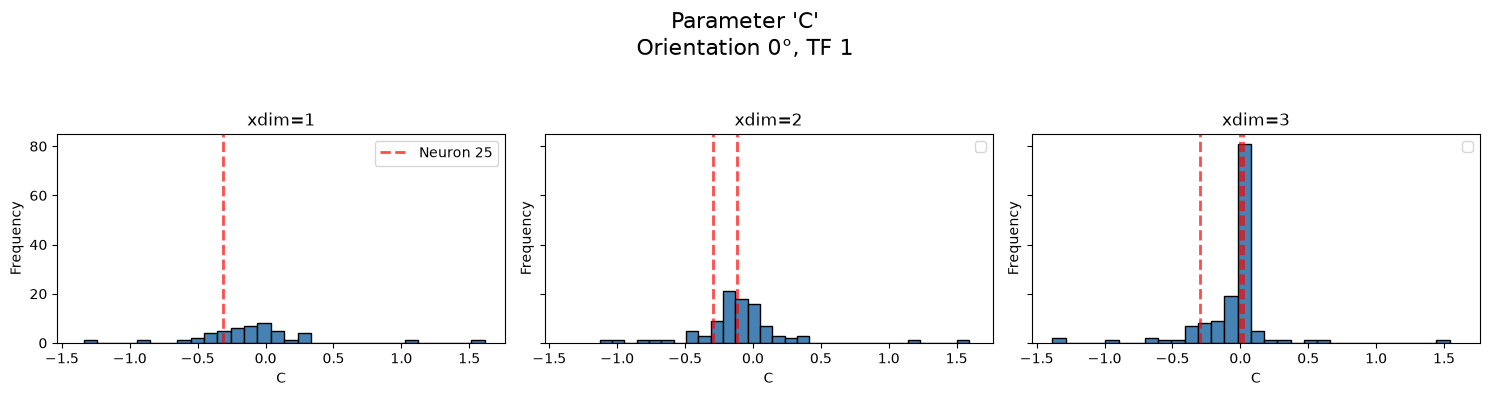

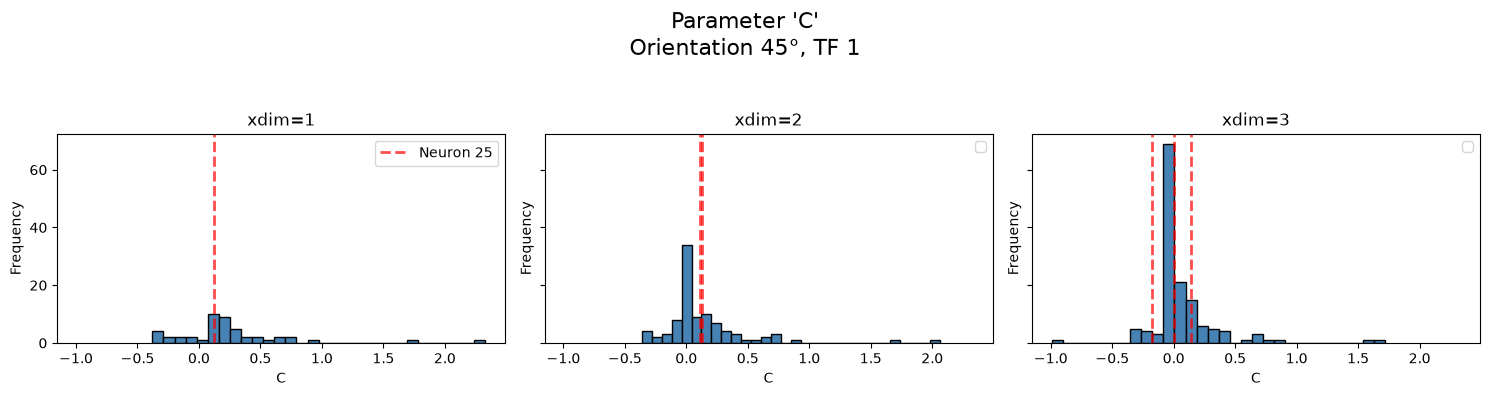

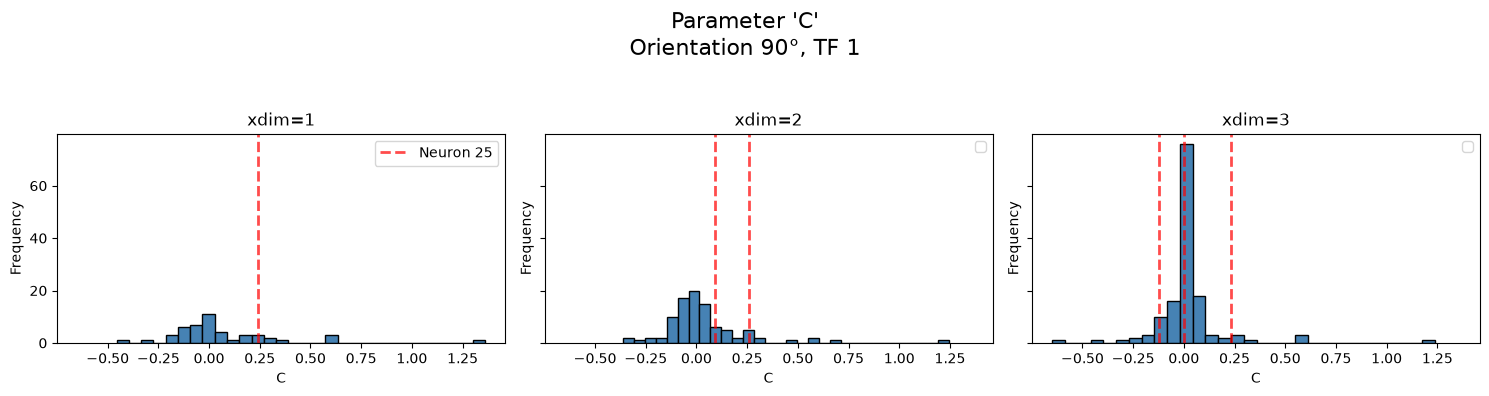

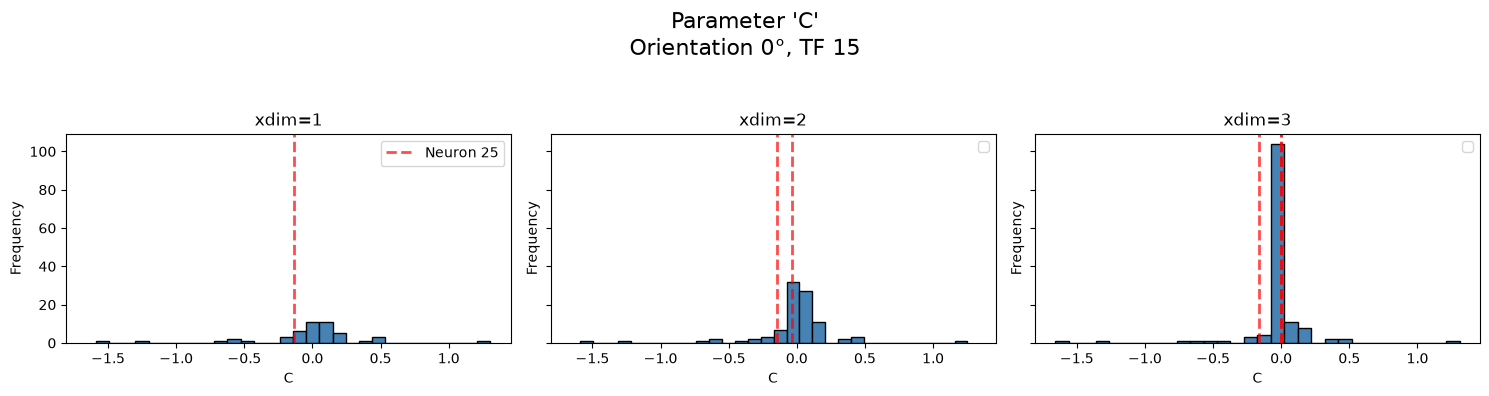

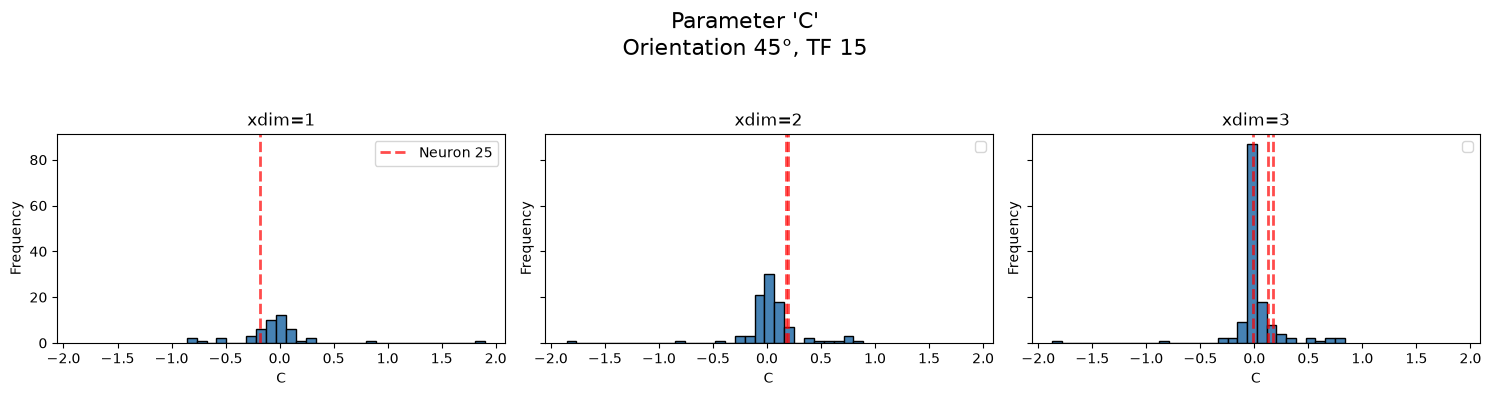

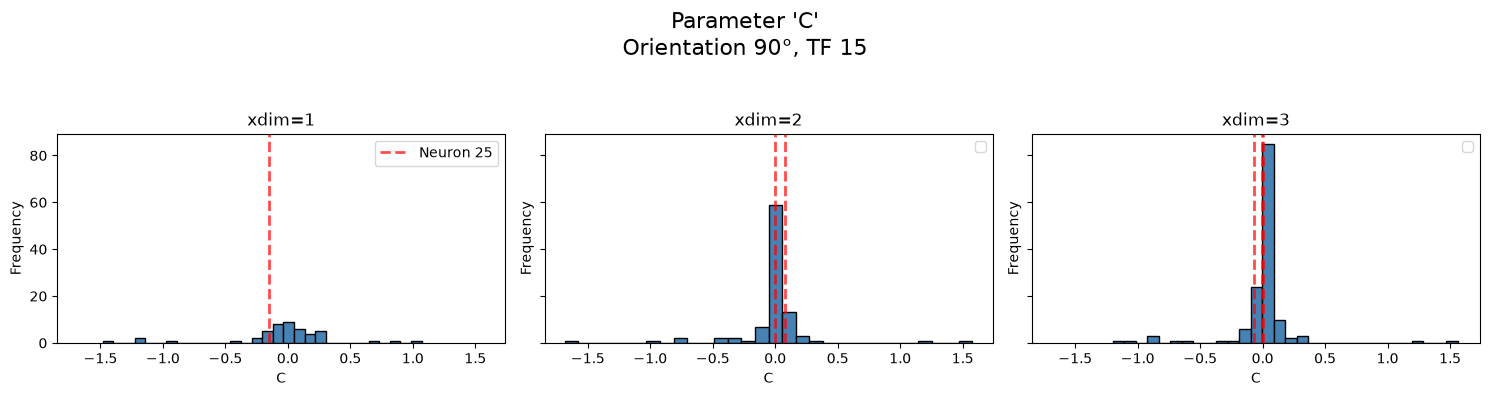

In [304]:
fig, axes = plot_param_histograms(
    fits, 
    orientation=0, 
    temporal_frequency=1, 
    param_name="C", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=45, 
    temporal_frequency=1, 
    param_name="C", 
    bins=30, 
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=90, 
    temporal_frequency=1, 
    param_name="C", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=0, 
    temporal_frequency=15, 
    param_name="C", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=45, 
    temporal_frequency=15, 
    param_name="C", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=90, 
    temporal_frequency=15, 
    param_name="C", 
    bins=30, 
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

/var/folders/_d/h8vy8lln5vg20dc2rt60305c0000gn/T/ipykernel_11192/2095609631.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


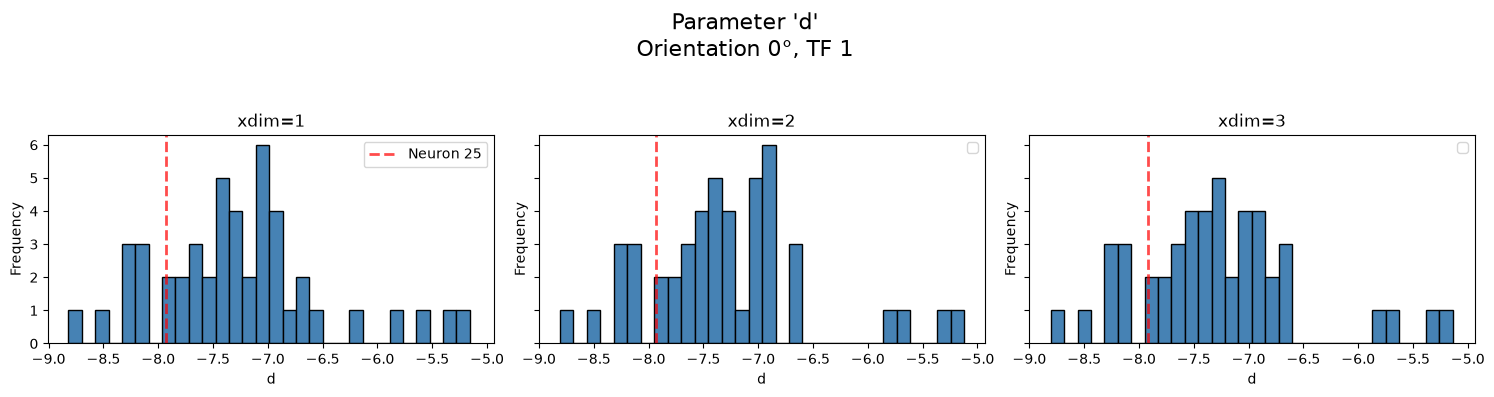

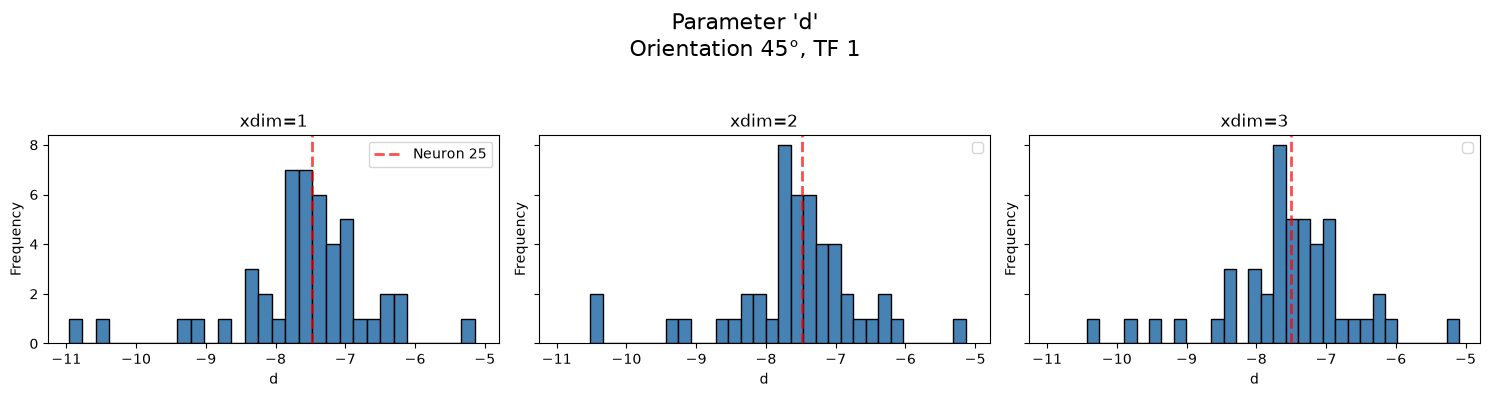

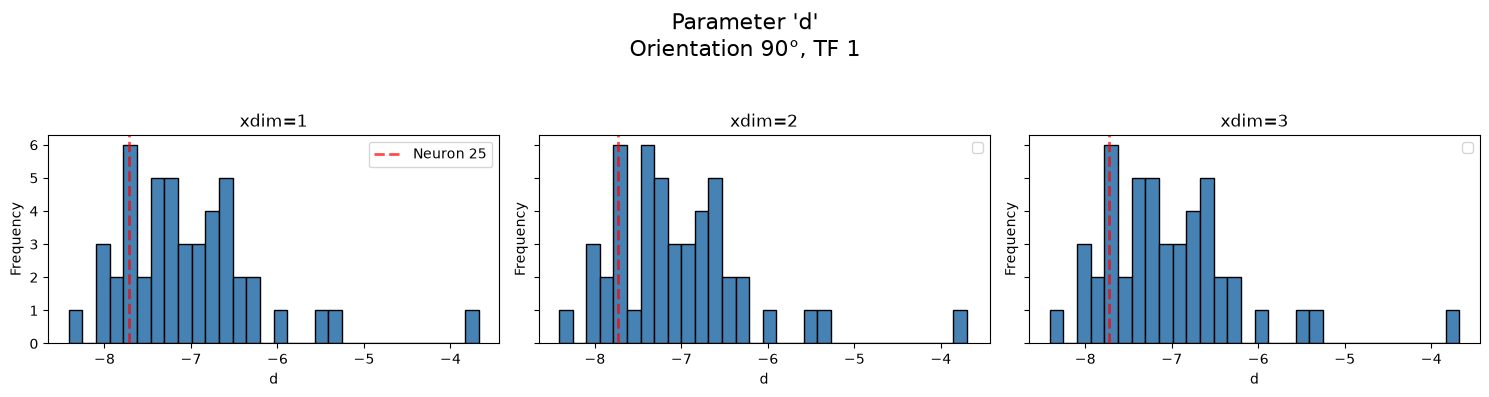

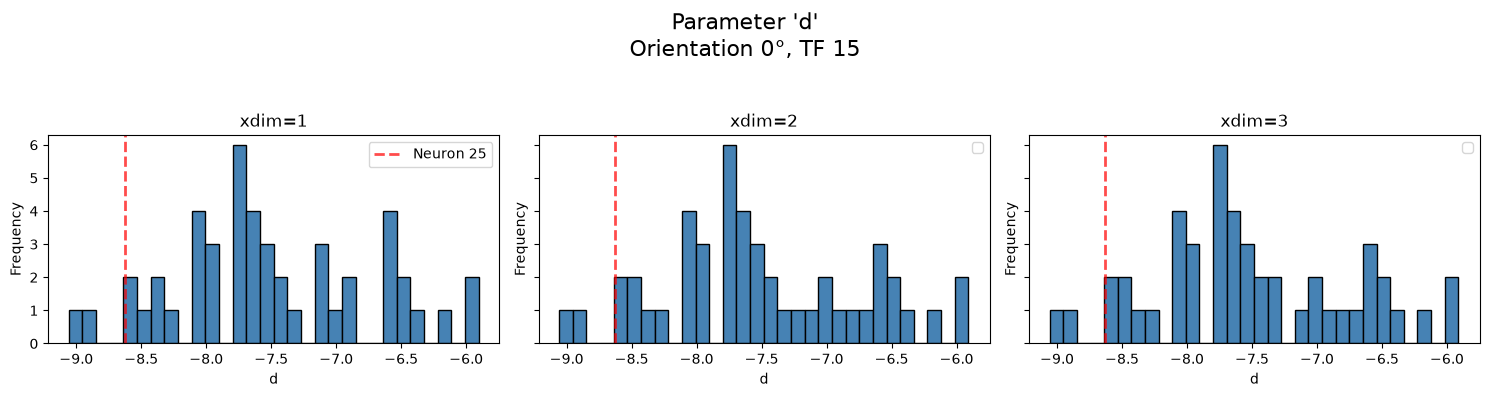

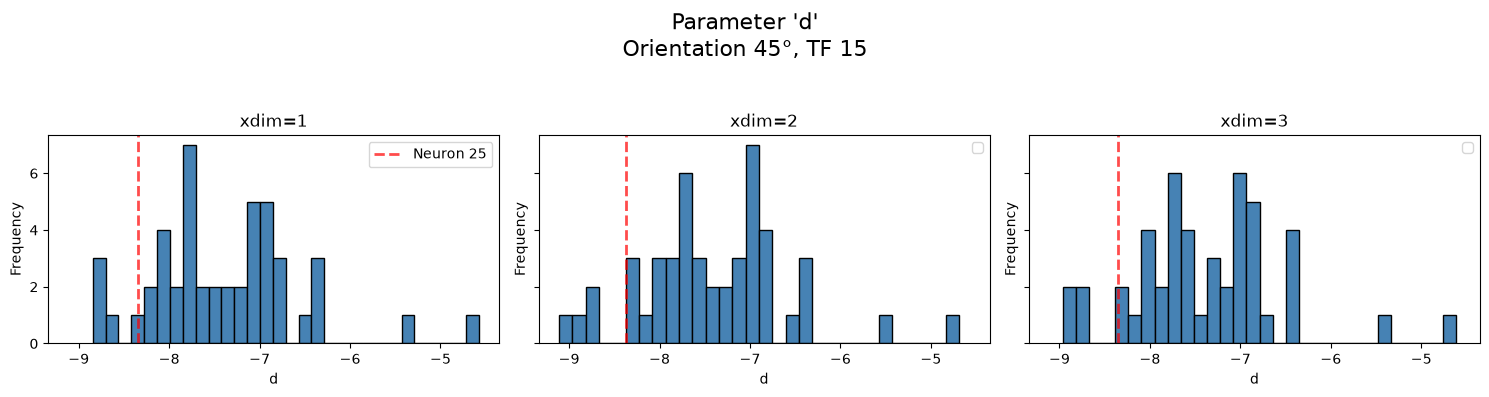

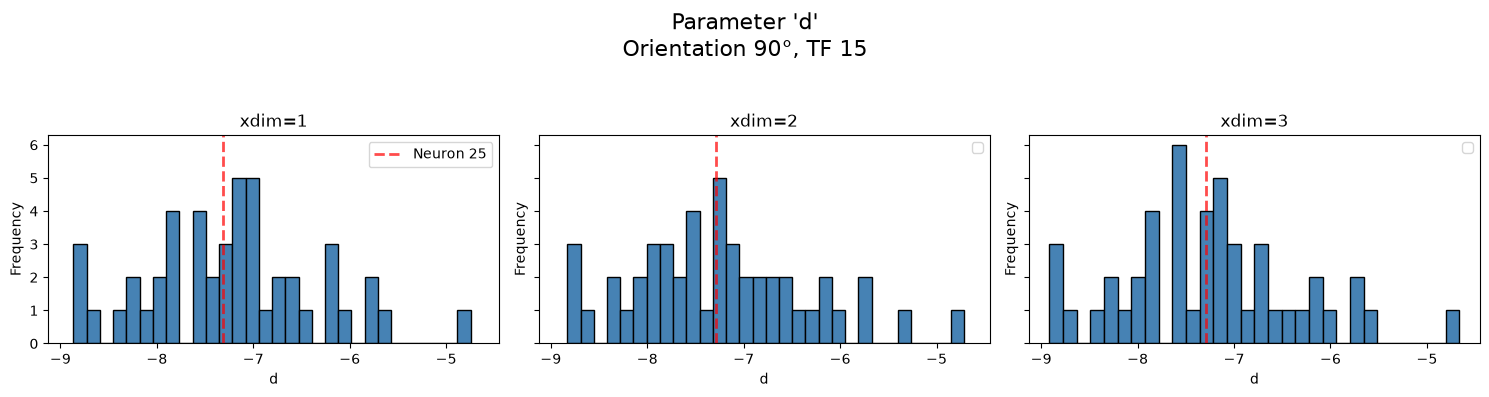

In [305]:
fig, axes = plot_param_histograms(
    fits, 
    orientation=0, 
    temporal_frequency=1, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=45, 
    temporal_frequency=1, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=90, 
    temporal_frequency=1, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=0, 
    temporal_frequency=15, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=45, 
    temporal_frequency=15, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

fig, axes = plot_param_histograms(
    fits, 
    orientation=90, 
    temporal_frequency=15, 
    param_name="d", 
    bins=30,
    neuron_idx=25  # example neuron index to highlight
)
plt.show()

## Compare latent trace with running speed

In [306]:
def plot_gpfa_latent_and_speed(fits, orientation, temporal_frequency, nr_trials=5):
    entry = fits.get((orientation, temporal_frequency))
    if entry is None:
        raise KeyError(f"No fits found for orientation={orientation}, temporal_frequency={temporal_frequency}")
    train_set, test_set, xval = entry

    model_fits = xval.fits
    data = model_fits[0].experiment  # the actual trials this xval's fits were trained on

    nr_trials = min(nr_trials, len(data.data))
    if nr_trials < 1:
        raise ValueError(f"No trained trials available for orientation={orientation}, temporal_frequency={temporal_frequency}.")

    n_cols = 1 + len(model_fits)
    fig, axes = plt.subplots(nr_trials, n_cols, figsize=(5 * n_cols, 3 * nr_trials), squeeze=False)
    time = np.arange(data.T) * (data.binSize / 1000.0)

    # start_idx -> post_mean index, built once per fit
    fit_start_maps = [
        {t["start_idx"]: i for i, t in enumerate(fit.experiment.data)}
        for fit in model_fits
    ]

    for row in range(nr_trials):
        trial = data.data[row]

        ax_raster = axes[row, 0]
        ax_raster.eventplot(trial["spike_time"], colors="black")
        ax_raster.set_title(f"Trial {row + 1}")
        ax_raster.set_xlabel("Time (s)")
        ax_raster.set_ylabel("Neuron Index")

        for col, fit in enumerate(model_fits, start=1):
            ax_speed = axes[row, col]
            ax_speed.plot(time, trial["running_speed"], color="blue", label="Running Speed")
            ax_speed.tick_params(axis="y", labelcolor="blue")
            ax_speed.set_ylabel("Running speed", color="blue")

            ax_latent = ax_speed.twinx()
            post_mean_idx = fit_start_maps[col - 1].get(trial["start_idx"])

            if post_mean_idx is not None:
                latent = fit.infRes["post_mean"][post_mean_idx]  # (xdim, T)
                for dim in range(latent.shape[0]):
                    label = f"Latent dim {dim}" if (row == 0 and col == 1) else None
                    ax_latent.plot(time, latent[dim], color="orange", alpha=0.8, label=label)
            else:
                ax_latent.text(0.5, 0.5, "no matching trial", ha="center", va="center",
                                transform=ax_latent.transAxes, fontsize=8, color="gray")

            ax_latent.tick_params(axis="y", labelcolor="orange")
            ax_latent.set_ylabel("Latent state", color="orange")

            xdim = fit.optimParams["C"].shape[1]
            if row == 0:
                ax_speed.set_title(f"xdim={xdim}", fontsize=10)
            if row == nr_trials - 1:
                ax_speed.set_xlabel("Time (s)", fontsize=10)

    fig.suptitle(f"Orientation {orientation:g}°, TF {temporal_frequency:g}", fontsize=20)

    lines_speed, labels_speed = axes[0, 1].get_legend_handles_labels()
    lines_latent, labels_latent = axes[0, 1].twinx().get_legend_handles_labels()
    fig.legend(lines_speed + lines_latent, labels_speed + labels_latent, fontsize=7, loc="upper right")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig, axes

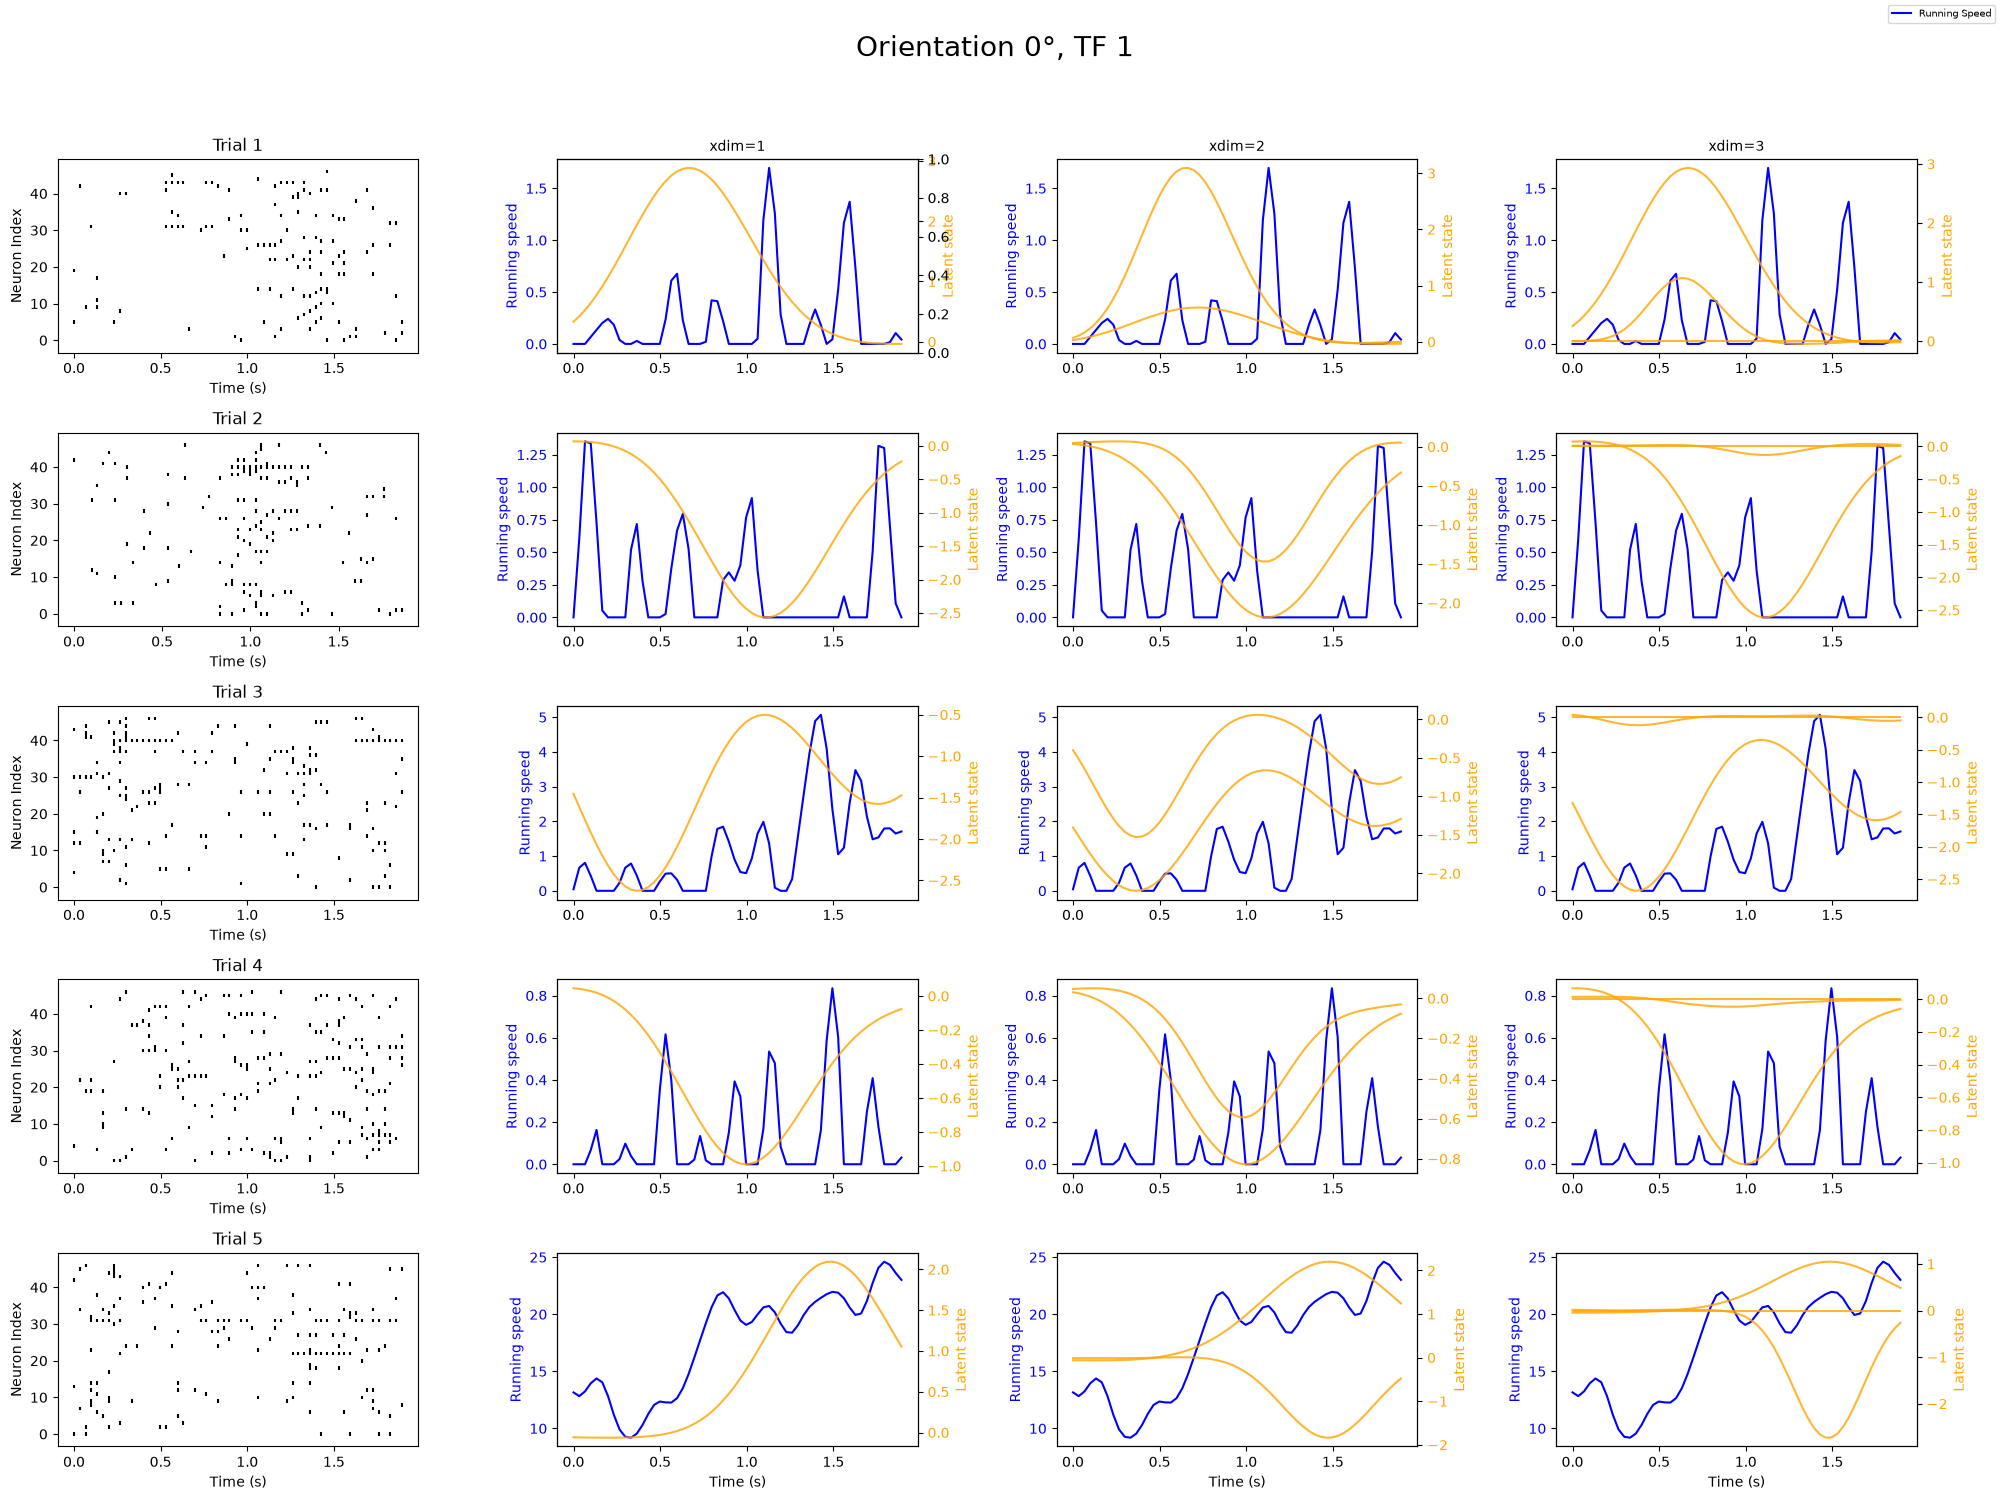

In [307]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=0, 
    temporal_frequency=1, 
    nr_trials=5
)
plt.show()

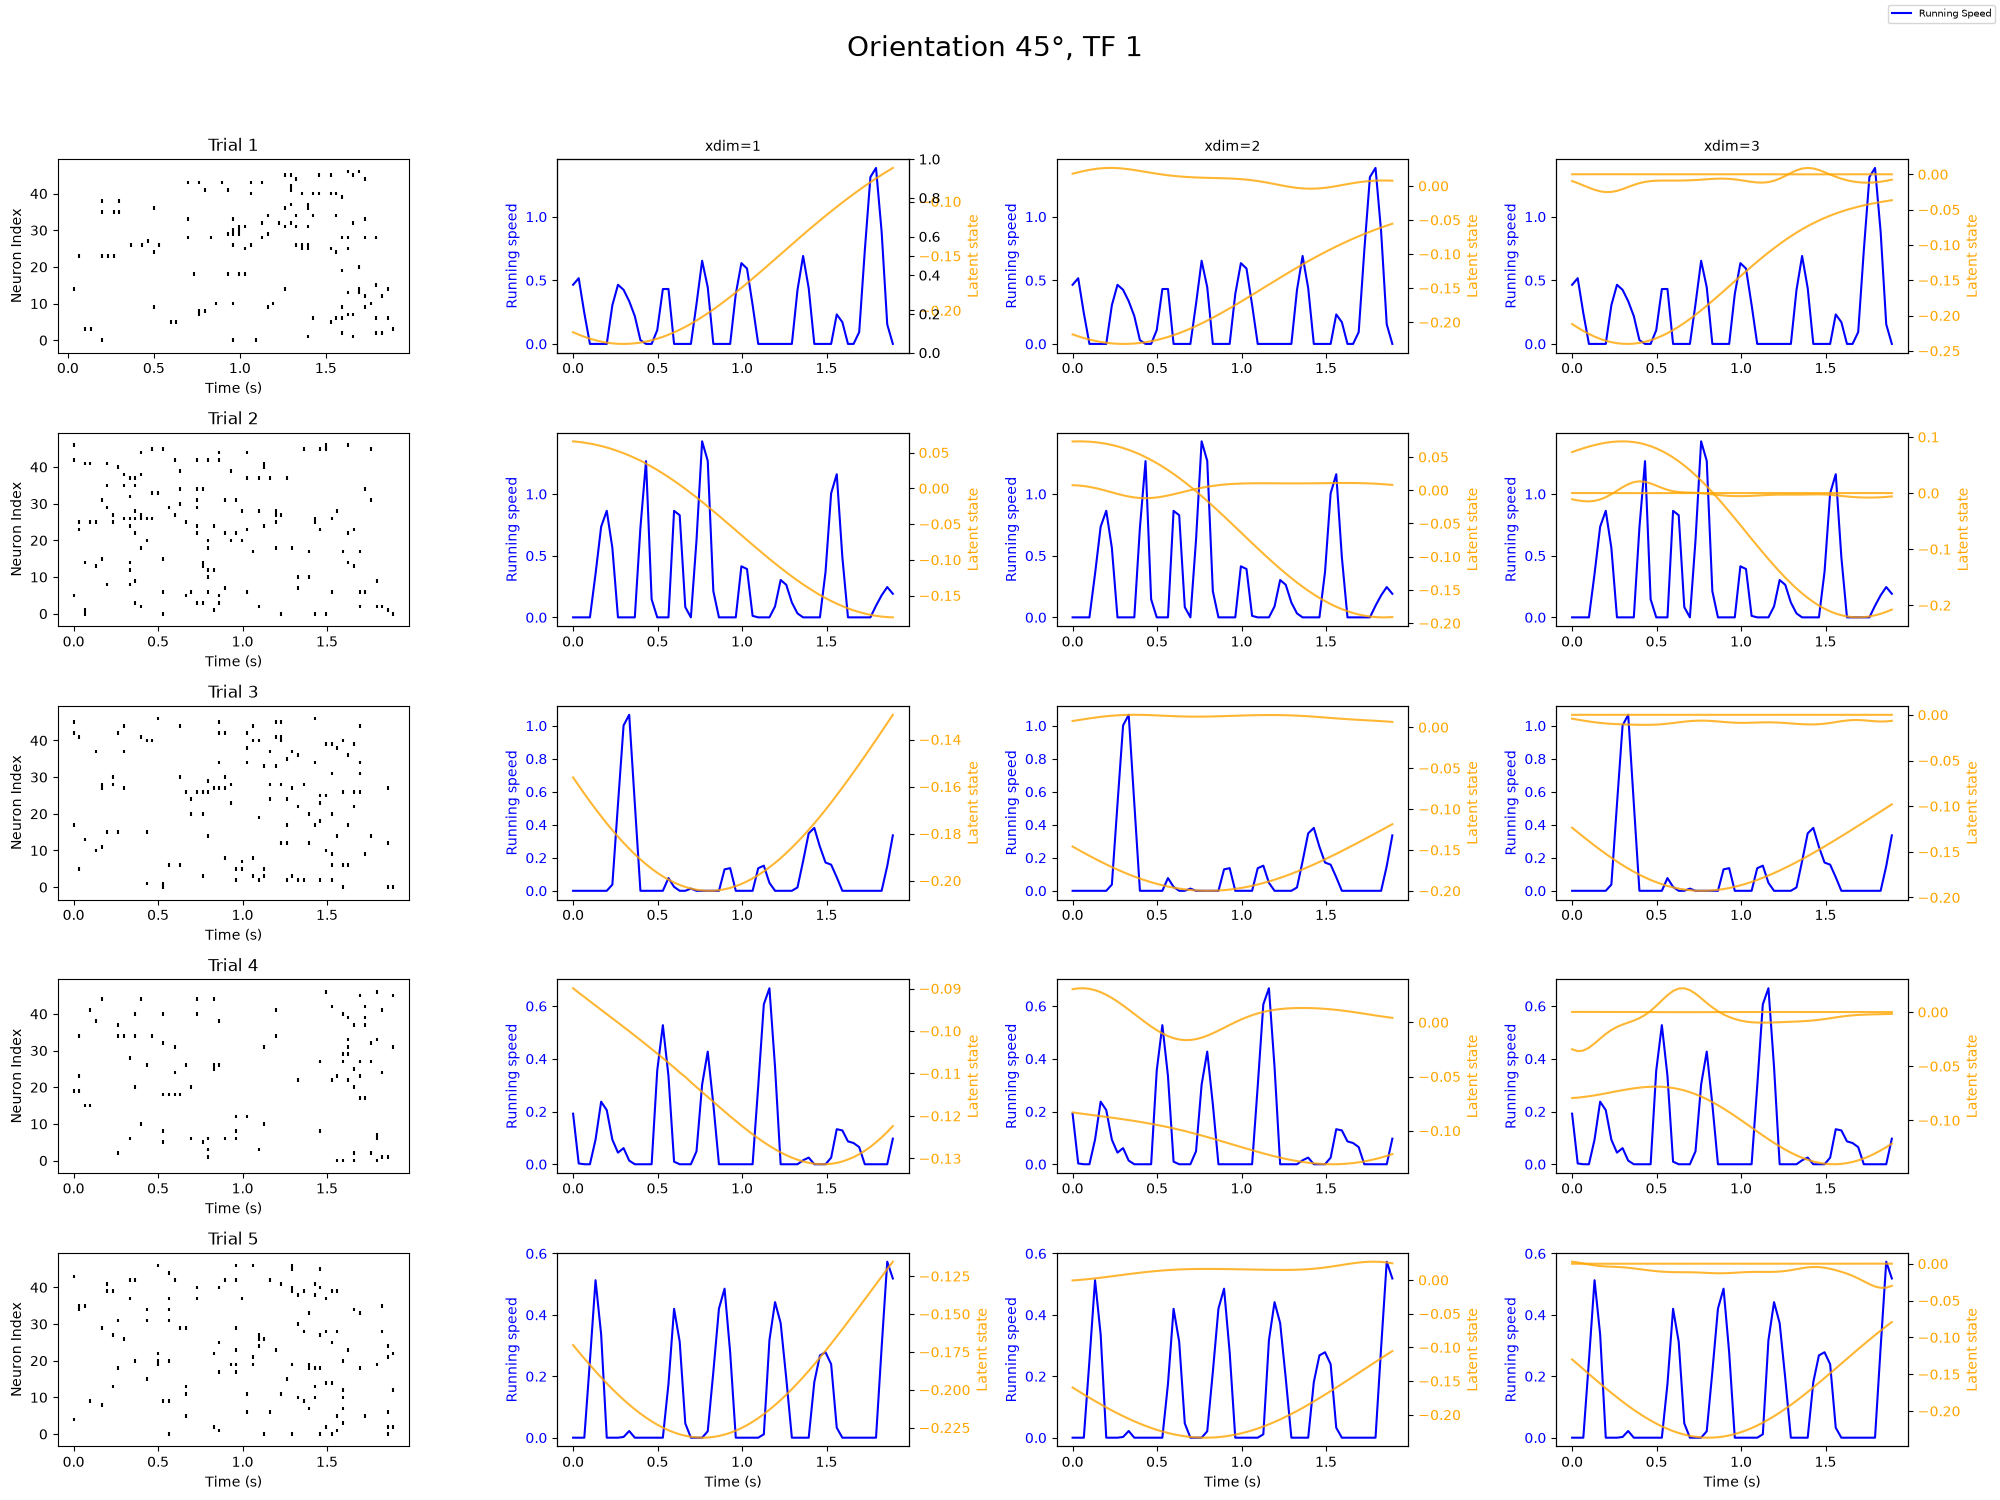

In [308]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=45, 
    temporal_frequency=1, 
    nr_trials=5
)
plt.show()

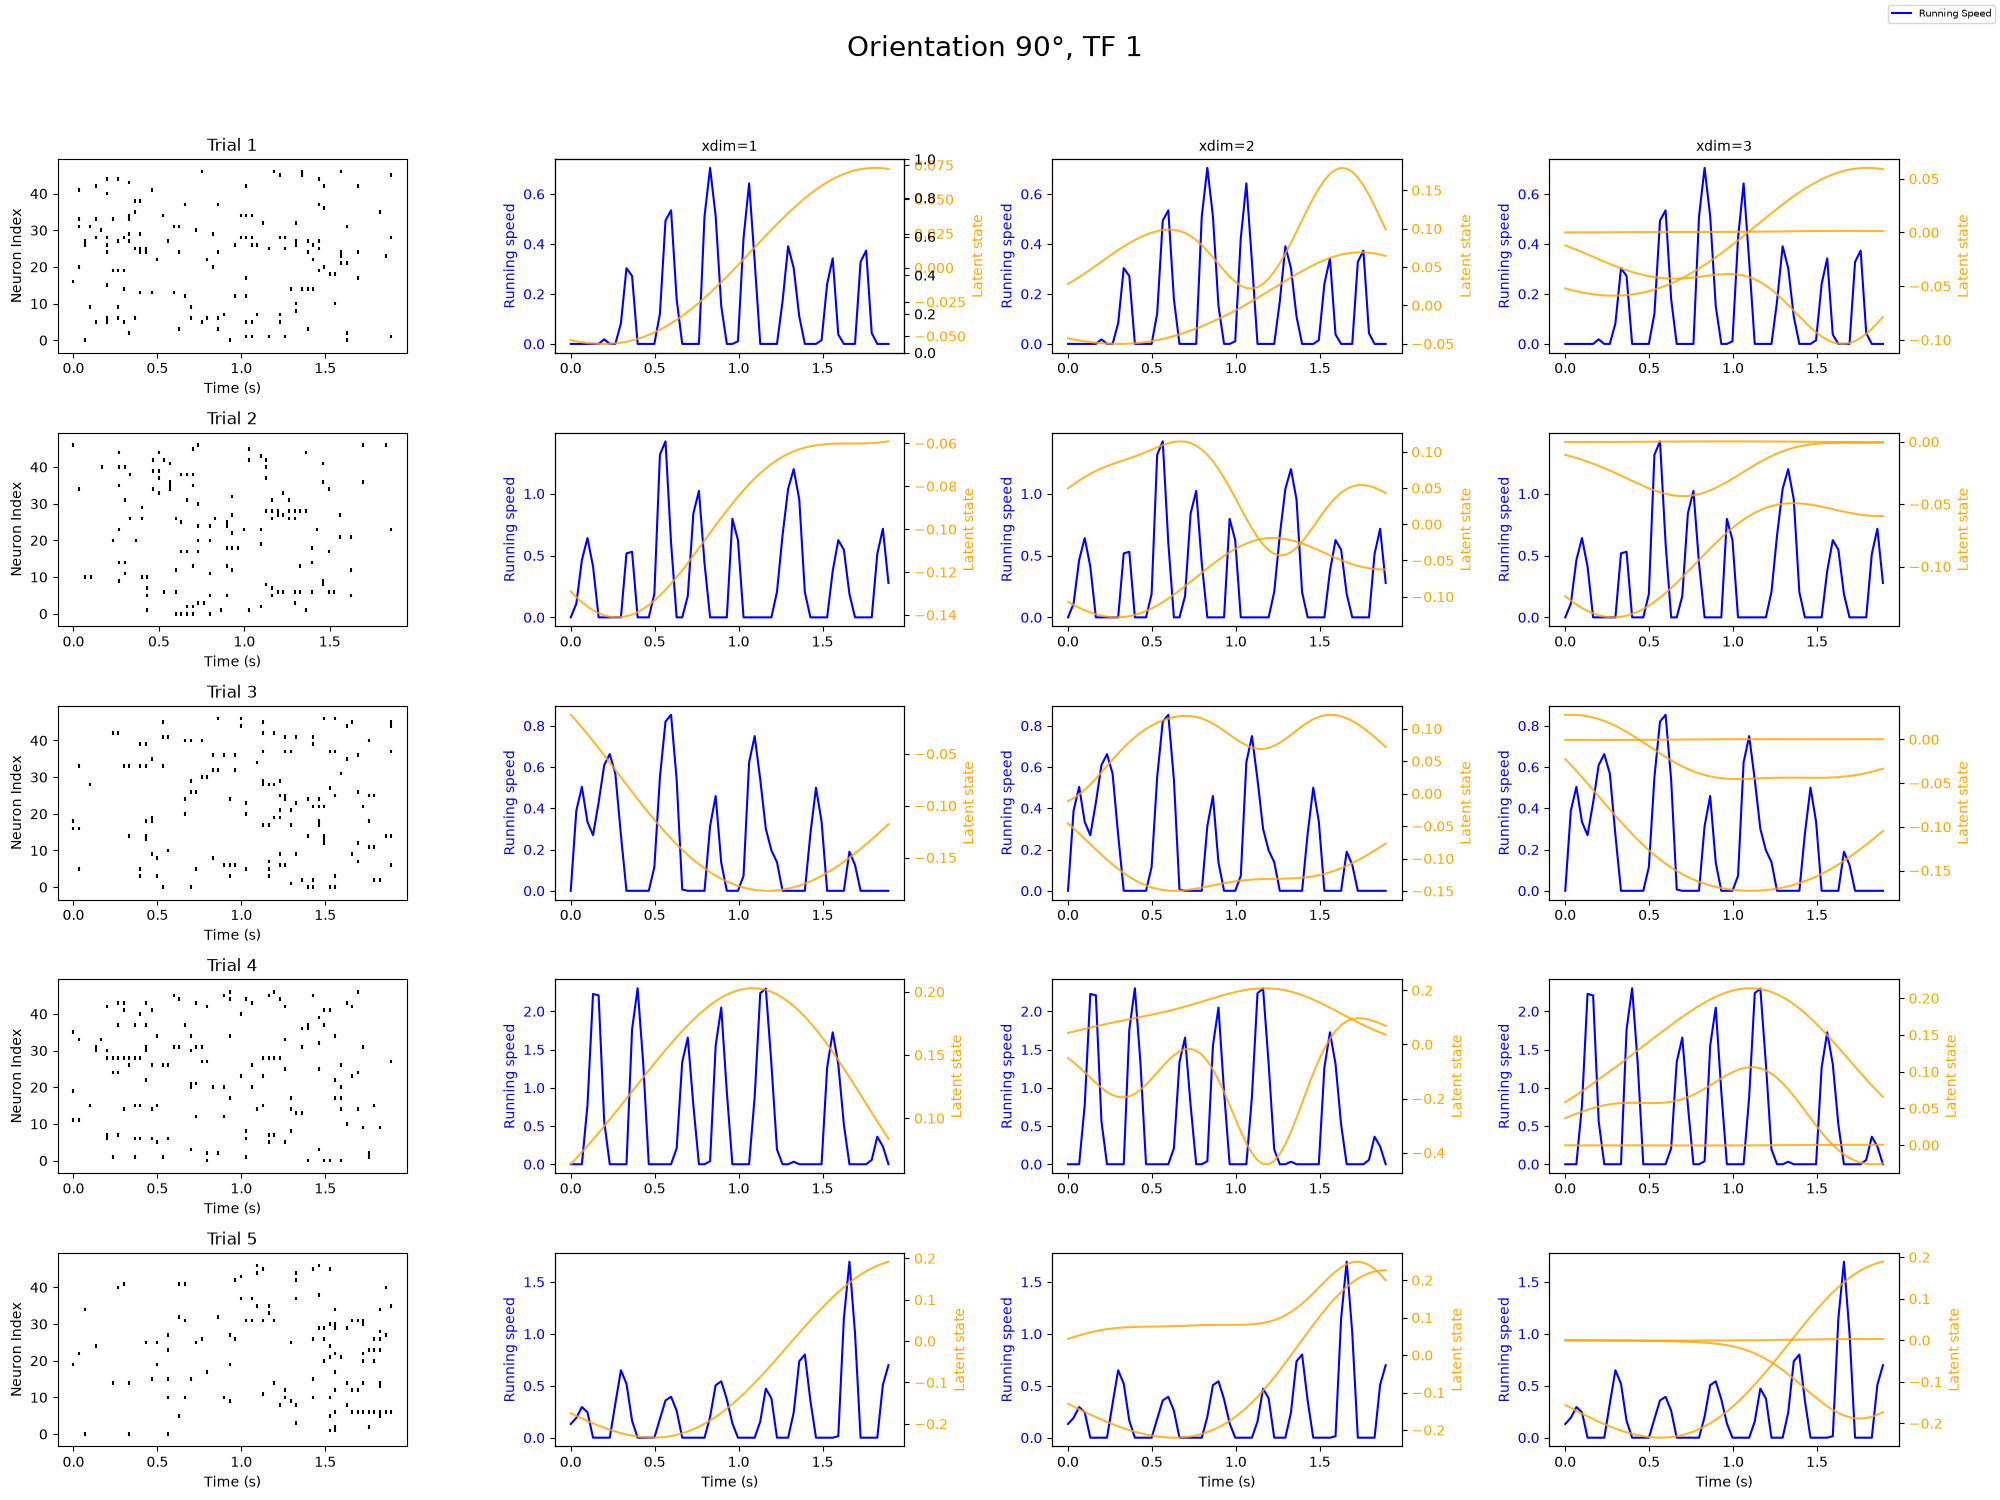

In [309]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=90, 
    temporal_frequency=1, 
    nr_trials=5
)
plt.show()

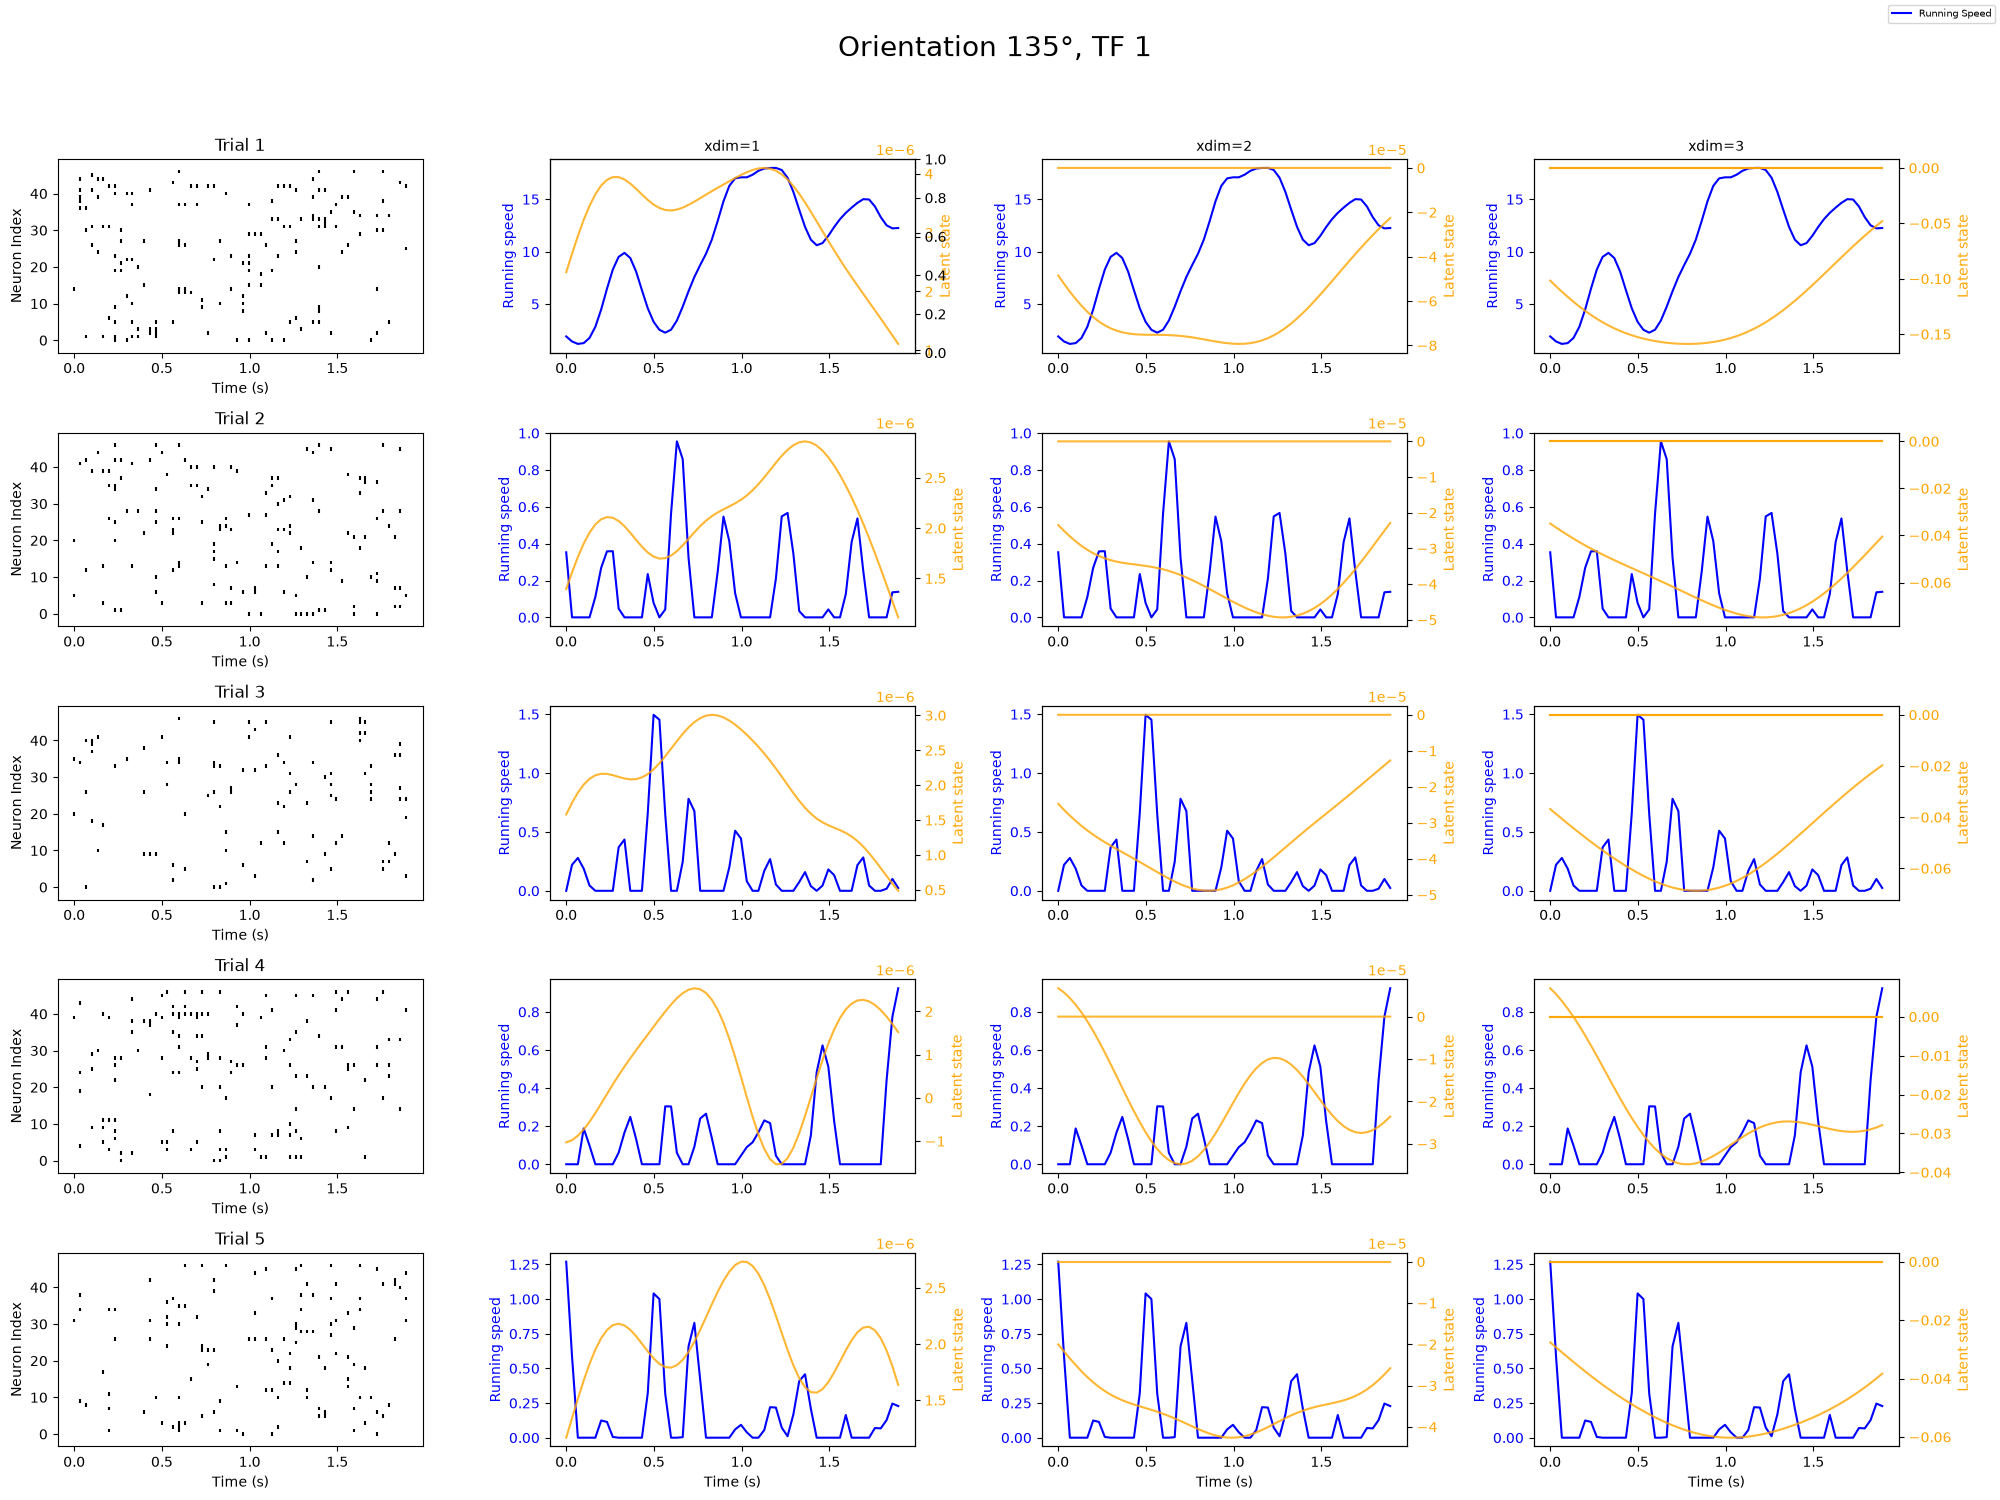

In [310]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=135, 
    temporal_frequency=1, 
    nr_trials=5
)
plt.show()

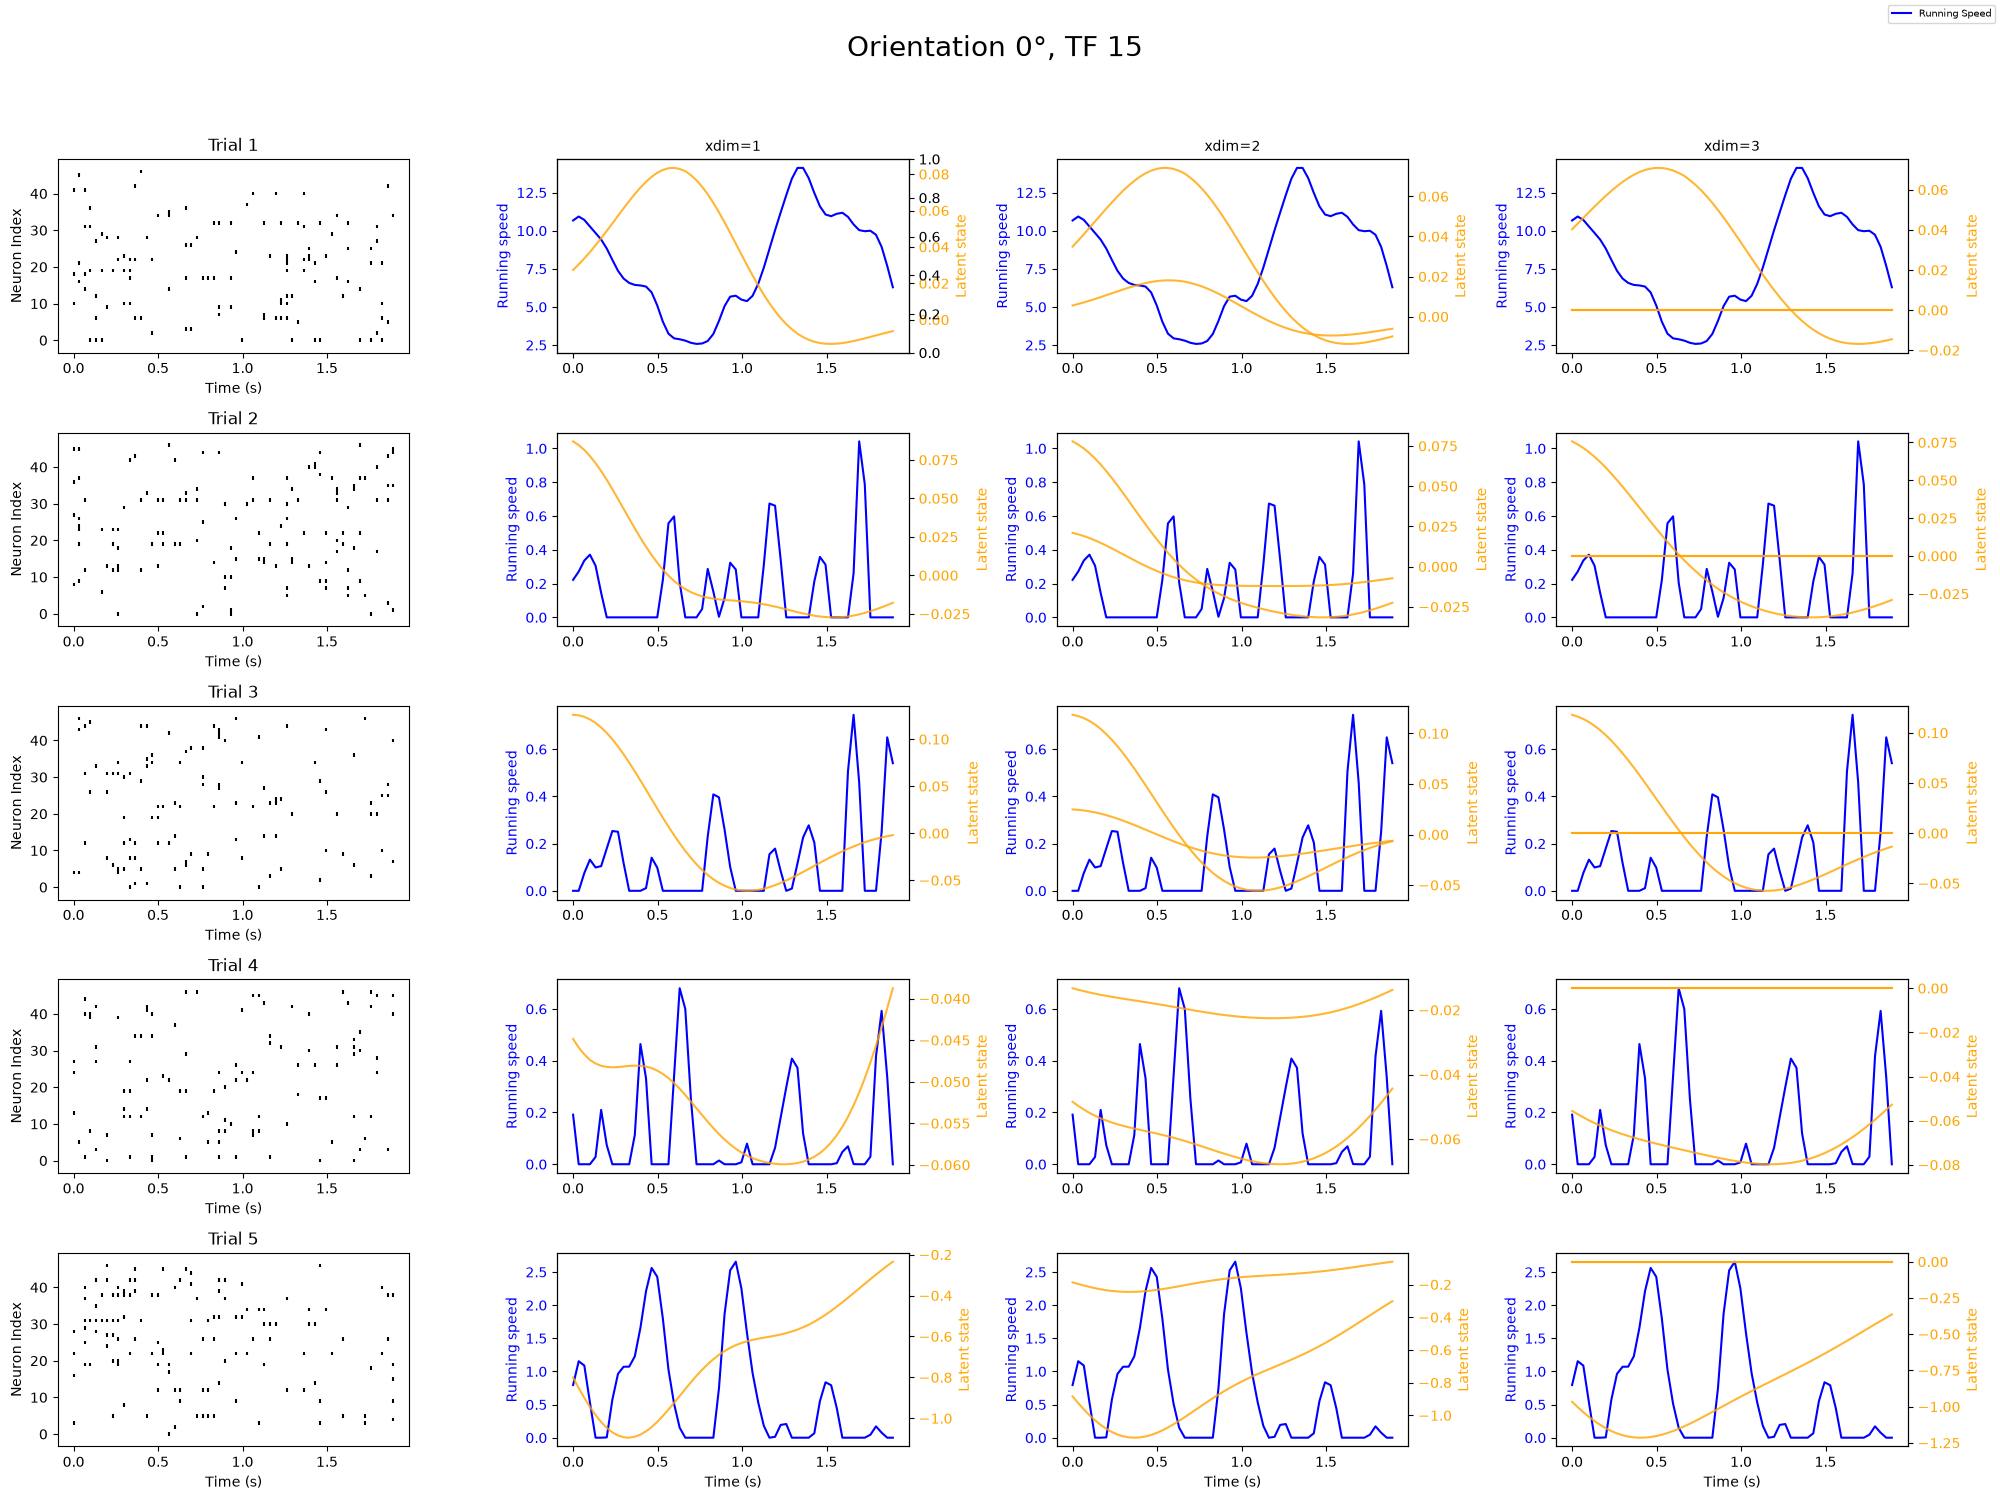

In [311]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=0, 
    temporal_frequency=15, 
    nr_trials=5
)
plt.show()

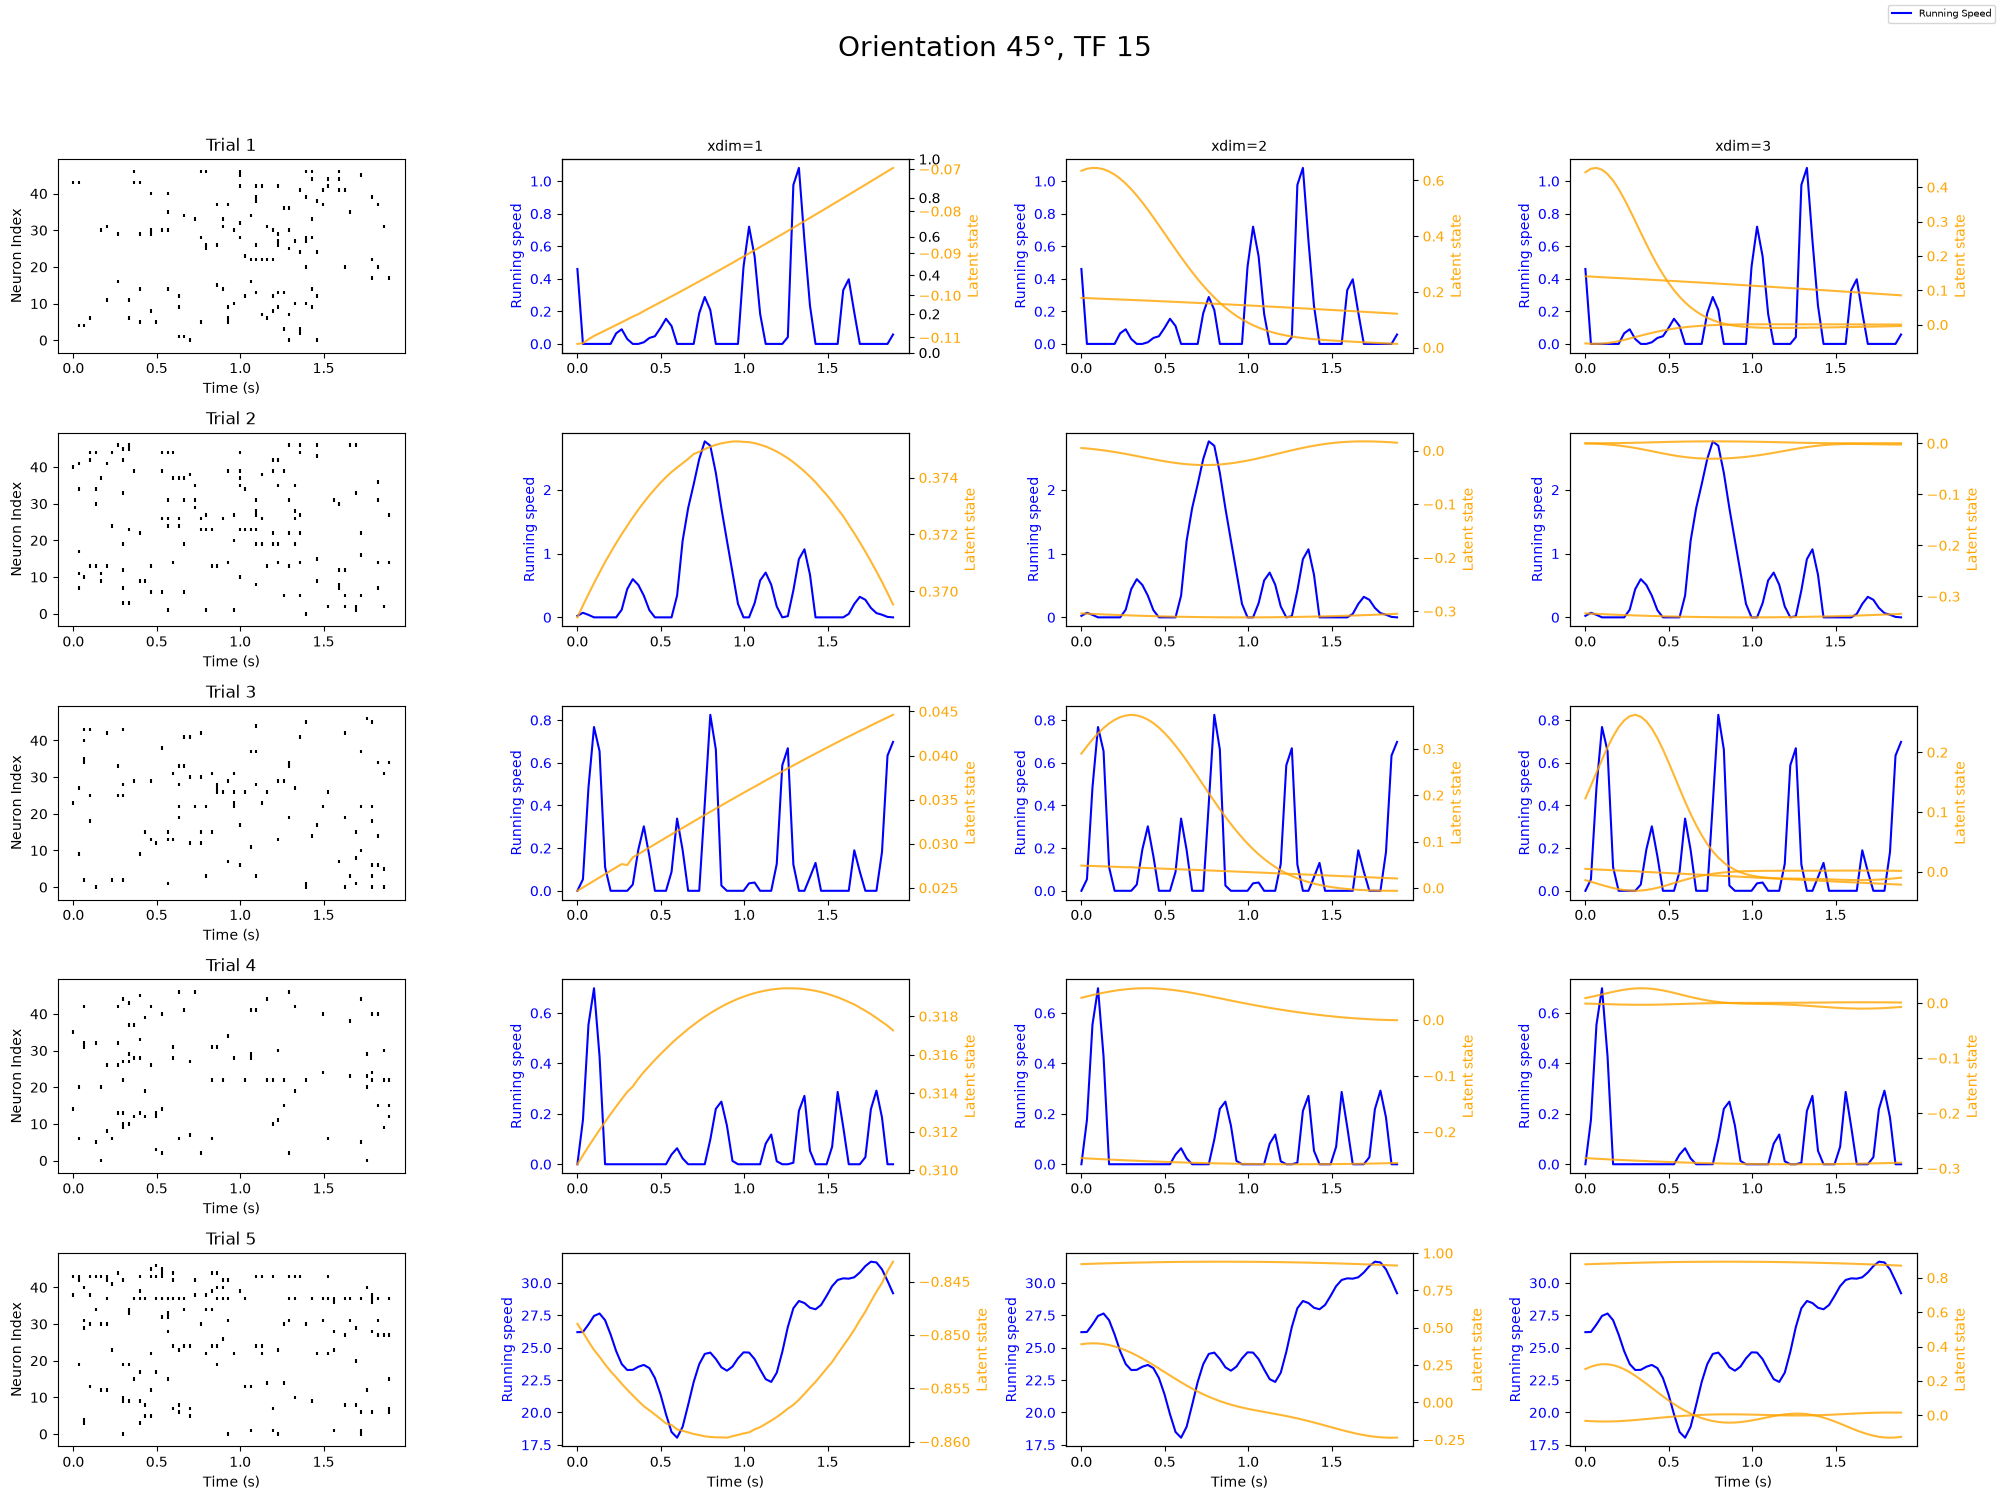

In [312]:
fig, axes = plot_gpfa_latent_and_speed(
    fits, 
    orientation=45, 
    temporal_frequency=15, 
    nr_trials=5
)
plt.show()